In [1]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd()))
from glob import glob
import math
from pprint import pprint
import torch

import pygarment as pyg
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import time

from tqdm import tqdm

import trimesh
from ANALYSIS.analysis_utils import (
    plot_panel_info,
    visualize_meshes_plotly,
    v_id_map
)

PROJECT_ROOT_PATH = "/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/"
GARMENT_ROOT_PATH = os.path.join(PROJECT_ROOT_PATH, "GarmentCodeData_v2")
BODY_ROOT_PATH = os.path.join(PROJECT_ROOT_PATH, "body_mesh")
MEAN_ALL_BODY_PATH = os.path.join(PROJECT_ROOT_PATH, "neutral_body/mean_all.obj")
    
default_body_mesh = trimesh.load(MEAN_ALL_BODY_PATH)

print("body vertices", default_body_mesh.vertices.shape)
print("body faces", default_body_mesh.faces.shape)

body vertices (23751, 3)
body faces (47500, 3)


In [22]:
import random


# BODY_TYPE = "random_body"
BODY_TYPE = "default_body"

garment_path_list = sorted(list(filter(
    os.path.isdir,
    glob(os.path.join(GARMENT_ROOT_PATH, "*", BODY_TYPE, "*"))
)))
IDX = random.randint(0, len(garment_path_list)-1)
garment_path = garment_path_list[IDX] 
# garment_path = "/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/GarmentCodeData_v2/garments_5000_0/default_body/rand_0BD28UCVO8"
# garment_path = "/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/GarmentCodeData_v2/garments_5000_0/default_body/rand_0AAY3NQH8J"
# garment_path = "/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/GarmentCodeData_v2/garments_5000_3/default_body/rand_005ZYVMOCL"
# garment_path = "/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/GarmentCodeData_v2/garments_5000_0/default_body/rand_0A36YXPNV0"
garment_id = os.path.basename(garment_path)

SPEC_FILE_PATH = os.path.join(garment_path, f"{garment_id}_specification.json")
print(SPEC_FILE_PATH)
pattern = pyg.pattern.wrappers.VisPattern(SPEC_FILE_PATH)

drawn_pattern_list = list(map(
    lambda pannel_name : pattern._draw_a_panel(
        pannel_name, apply_transform=False, fill=True
    ),
    pattern.panel_order()
))
# drawn_pattern_list[4]

/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/GarmentCodeData_v2/garments_5000_6/default_body/rand_DT3KMIYI0Y/rand_DT3KMIYI0Y_specification.json


In [23]:
pattern.panel_order()

['skirt_panel_6',
 'skirt_panel_0',
 'skirt_panel_1',
 'right_btorso',
 'right_ftorso',
 'skirt_panel_5',
 'wb_back',
 'wb_front',
 'skirt_panel_2',
 'left_btorso',
 'left_ftorso',
 'skirt_panel_4',
 'skirt_panel_3']

In [8]:
# # TODO: Garment Arc 없는 경우 처리
# # json content root load
# # 30427
# IDX = 50
# import json
# import random

# json_file_path = "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/garment_without_arc_list.json"

# def load_json_file(file_path):
#     with open(file_path, 'r') as file:
#         data = json.load(file)
#     return data

# json_data = load_json_file(json_file_path)
# print(json_data[0])
# len(json_data)

/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/GarmentCodeData_v2/garments_5000_14/default_body/rand_8SO8WAA1A6


30427

In [263]:
# import json
# unique_panel_names = set()
# # ALL IDX GARMENT PATH  
# garment_path_list = sorted(list(filter(
#     os.path.isdir,
#     glob(os.path.join(GARMENT_ROOT_PATH, "*", BODY_TYPE, "*"))
# )))
# for idx, garment_path in enumerate(garment_path_list):
#     garment_id = os.path.basename(garment_path)
#     SPEC_FILE_PATH = os.path.join(garment_path, f"{garment_id}_specification.json")
#     if os.path.exists(SPEC_FILE_PATH):
#         # Load the JSON file
#         with open(SPEC_FILE_PATH, 'r') as file:
#             spec_data = json.load(file)
        
#         # Extract panel names from the nested structure and add to the set
#         if 'pattern' in spec_data and 'panels' in spec_data['pattern']:
#             for panel_name in spec_data['pattern']['panels']:
#                 print(panel_name)
#                 unique_panel_names.add(panel_name)

# # unique_panel_names look data frame
# import pandas as pd
# df = pd.DataFrame(unique_panel_names)
# df.to_csv("/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/nique_panel_names.csv", index=False)


In [4]:
# #garment_path_list[0]
# #panel_svg_path_dict['right_ftorso']
# import json
# FILE_PATH = "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/asd.json"

# with open(FILE_PATH, "r") as f:
#     data = json.load(f)

# with open(FILE_PATH, "w") as f:
#     json.dump(data, f, indent=4)

In [18]:
import numpy as np

theta_start =np.angle(complex(-10, -10)) + 2*np.pi
theta_end = np.angle(complex(10, 10))
print(theta_start, theta_end)


3.9269908169872414 0.7853981633974483


Converted Bezier Curve Data:
{'start_x': 130.1925, 'start_y': 398.36598, 'control_x': np.float64(110.5071174009993), 'control_y': np.float64(268.6472226424269), 'end_x': 238.3805, 'end_y': 298.021843}


In [210]:
# data = panel_svg_path_dict['right_btorso'][0][11]
# print(data)

panel_dataframes = [process_path_data(drawn_pattern) for drawn_pattern in drawn_pattern_list]
print(panel_dataframes)

[            type                radius  rotation large_arc  sweep     start_x  \
0   Bezier Curve        NaN+ 0.000000j       NaN      None   None  238.380500   
1       Straight        NaN+ 0.000000j       NaN      None   None  170.038765   
2       Straight        NaN+ 0.000000j       NaN      None   None  153.511165   
3   Bezier Curve        NaN+ 0.000000j       NaN      None   None  152.282837   
4       Straight        NaN+ 0.000000j       NaN      None   None  106.885369   
5       Straight        NaN+ 0.000000j       NaN      None   None   85.552684   
6   Bezier Curve        NaN+ 0.000000j       NaN      None   None   89.213325   
7       Straight        NaN+ 0.000000j       NaN      None   None    7.116917   
8       Straight        NaN+ 0.000000j       NaN      None   None    0.000000   
9   Bezier Curve        NaN+ 0.000000j       NaN      None   None    0.000000   
10      Straight        NaN+ 0.000000j       NaN      None   None   66.096500   
11           Arc  10.849458

In [227]:
panel_dataframes = [process_path_data(drawn_pattern) for drawn_pattern in drawn_pattern_list]
row1 = panel_dataframes[0].iloc[11]

In [229]:
panel_dataframes[0].iloc[11]

type                                               Arc
radius        (108.49457592383715+108.49457592383715j)
rotation                                           0.0
large_arc                                        False
sweep                                            False
start_x                                       130.1925
start_y                                      398.36598
controla_x                                         NaN
controla_y                                   398.36598
controlb_x                                         NaN
controlb_y                                   398.36598
control1_x                                         NaN
control1_y                                   398.36598
control2_x                                         NaN
control2_y                                   398.36598
end_x                                         238.3805
end_y                                       298.021843
Name: 11, dtype: object

In [238]:
import math

def arc_to_bezier_fixed(start_x, start_y, end_x, end_y, radius, rotation, large_arc, sweep):
    # Arc 중심 계산
    cx = (start_x + end_x) / 2
    cy = (start_y + end_y) / 2

    # 호의 시작 각도와 끝 각도 계산
    start_angle = math.atan2(start_y - cy, start_x - cx)
    end_angle = math.atan2(end_y - cy, end_x - cx)

    # 방향에 따른 각도 범위 설정
    if not sweep and end_angle > start_angle:
        end_angle -= 2 * math.pi
    elif sweep and end_angle < start_angle:
        end_angle += 2 * math.pi

    # 각도 범위를 분할 (90도 이하)
    delta_angle = end_angle - start_angle
    num_segments = max(int(abs(delta_angle) / (math.pi / 2)) + 1, 1)
    angle_step = delta_angle / num_segments

    # Bézier Curve로 변환
    bezier_curves = []
    for i in range(num_segments):
        theta1 = start_angle + i * angle_step
        theta2 = start_angle + (i + 1) * angle_step

        # Control point 계산
        t = math.tan((theta2 - theta1) / 4) * (4 / 3)
        if i == 0:
            x1, y1 = start_x, start_y  # Arc의 시작점 고정
        else:
            x1 = radius * math.cos(theta1) + cx
            y1 = radius * math.sin(theta1) + cy

        if i == num_segments - 1:
            x2, y2 = end_x, end_y  # Arc의 끝점 고정
        else:
            x2 = radius * math.cos(theta2) + cx
            y2 = radius * math.sin(theta2) + cy

        cx1 = x1 - t * radius * math.sin(theta1)
        cy1 = y1 + t * radius * math.cos(theta1)
        cx2 = x2 + t * radius * math.sin(theta2)
        cy2 = y2 - t * radius * math.cos(theta2)

        bezier_curves.append(((x1, y1), (cx1, cy1), (cx2, cy2), (x2, y2)))

    return bezier_curves

In [113]:
# drawn_pattern_list
panel_dataframes = process_path_data(drawn_pattern_list)
# print(panel_dataframes)
# for a in panel_dataframes.iterrows():
#     print(a)
#start_x
for idx, row in panel_dataframes.iterrows():
   print(row['start_x'])

238.38049999999998
nan
nan


In [47]:
arc_info = panel_svg_path_dict['right_btorso'][0]
print(arc_info)

Path(Line(start=(25.0299525+51.27586167187688j), end=51.27586167187688j),
     Line(start=51.27586167187688j, end=37.29251592013509j),
     CubicBezier(start=37.29251592013509j, control1=(13.245869699092289+33.345596895653784j), control2=(10.578238649481309+22.159170421431817j), end=(7.8015525+3.905203922728546j)),
     Line(start=(7.8015525+3.905203922728546j), end=(17.62602411310757+0j)),
     Arc(start=(17.62602411310757+0j), radius=(7.415211594915708+7.415211594915708j), rotation=0, large_arc=False, sweep=False, end=(25.0299525+7.006301532505212j)),
     Line(start=(25.0299525+7.006301532505212j), end=(25.0299525+51.27586167187688j)))


In [48]:
arc_info = arc_info[4]
start_x, start_y = arc_info.start.real, arc_info.start.imag
end_x, end_y = arc_info.end.real, arc_info.end.imag
radius_x, radius_y = arc_info.radius.real, arc_info.radius.imag
rotation_angle = arc_info.rotation
large_arc = arc_info.large_arc
sweep = arc_info.sweep
print(start_x, start_y, end_x, end_y, radius_x, radius_y, rotation_angle, large_arc, sweep)

17.62602411310757 0.0 25.0299525 7.006301532505212 7.415211594915708 7.415211594915708 0 False False


In [161]:
a={
        "start_x": 11.1, "start_y": 11.1,
        "control1_x": 11.1, "control1_y": 11.1,
        "control2_x": 11.1, "control2_y": 11.1,
        "end_x": 12.3, "end_y": 1.2,
    }

for t in a.values():
    print(t)

In [240]:
import math

def arc_to_cubic_bezier(
    x1, y1, x2, y2,
    rx, ry,
    large_arc_flag, sweep_flag
):
    """
    rotation = 0 이고 rx=ry=r 인 원호(arc)를
    단일 Cubic Bézier로 근사했을 때의
    (c1x, c1y, c2x, c2y, x2, y2)를 반환.
    (여기서는 start point = (x1, y1)을 이미 알고 있으니, 
     출력에서 end point는 x2, y2로 고정)
    """
    # ---------- 1) 중간값(미드포인트) ----------
    mx = (x1 + x2) / 2.0
    my = (y1 + y2) / 2.0
    
    # ---------- 2) 회전 0이므로, 간단히 x1', y1' ----------
    #     x1' = (x1 - x2)/2
    #     y1' = (y1 - y2)/2
    #     등을 구해서 중심(CCx, CCy) 찾기
    dx_ = (x1 - x2) / 2.0
    dy_ = (y1 - y2) / 2.0
    
    # 호가 그려지려면, r이 chord보다 커야 하므로 보정이 필요할 수도 있음
    # 여기서는 문제에서 주어진 r이 충분히 크다고 가정
    
    # chord의 제곱
    chord_sq = dx_*dx_ + dy_*dy_
    r_sq = rx*rx  # rx=ry=r인 경우
    
    # ---------- 3) 중심 구하기 ----------
    # SVG 스펙에서, largeArcFlag와 sweepFlag가 같은 경우 음수 부호,
    #                 다른 경우 양수 부호를 사용한다.
    #     c'_x = ± λ * ( rx * y1' / ry )
    #     c'_y = ∓ λ * ( ry * x1' / rx )
    # 여기서는 rx=ry=r, rotation=0이라 간단해진 형태.
    sign = -1.0 if (large_arc_flag == sweep_flag) else 1.0
    
    # λ = sqrt( (r^2 - chord^2/4) / (chord^2/4) ) = sqrt( r^2/chord^2 - 1 )
    # 실제 SVG 공식과 살짝 다를 수 있으나 개념은 동일
    chord_half_sq = chord_sq / 4.0
    factor = math.sqrt(max(r_sq / chord_half_sq - 1.0, 0.0))
    
    cx_ =  sign * factor * (dy_)
    cy_ = -sign * factor * (dx_)
    
    # 다시 원래 좌표계로 되돌리려면, (mx, my)를 더해 준다.
    # (mx, my)는 ( (x1 + x2)/2, (y1 + y2)/2 )
    cx = cx_ + mx
    cy = cy_ + my
    
    # ---------- 4) 각도 구하기 (시작각 a1, 끝각 a2) ----------
    # 벡터: v1 = (x1 - cx, y1 - cy), v2 = (x2 - cx, y2 - cy)
    vx1, vy1 = (x1 - cx), (y1 - cy)
    vx2, vy2 = (x2 - cx), (y2 - cy)
    
    # atan2로 각도 구함
    a1 = math.atan2(vy1, vx1)
    a2 = math.atan2(vy2, vx2)
    
    # 실제 sweepFlag=False 이므로 (a2 - a1)가 음수가 되도록 맞춘 호가 그려짐
    # 호의 크기(절댓값)
    dtheta = a2 - a1
    
    # 일반적으로 sweepFlag=False(반시계 반대 방향)라면
    # dtheta가 음수가 되어야 작은 쪽 각이 될 것
    # 필요시 2π 조정:
    if sweep_flag and dtheta < 0:
        dtheta += 2*math.pi
    elif (not sweep_flag) and dtheta > 0:
        dtheta -= 2*math.pi
    
    # 이제 arc의 절댓값(중심각) = |dtheta|
    # 이 값이 90도(π/2 rad) 이하라면 단일 3차 베지어 근사가 그럭저럭 쓸 만함
    
    # ---------- 5) 단일 호를 3차 베지어로 근사하기 ----------
    # (원점+반지름) 기준 공식:
    #   P0 = (r cos a1, r sin a1)
    #   P3 = (r cos a2, r sin a2)
    #   α  = (4/3) tan(|dtheta|/4)
    #   P1 = P0 + α * ( -r sin a1,  r cos a1 )  [호를 양의 방향으로 볼 때]
    #       (단, dtheta<0 이면 부호가 뒤집힘에 주의)
    #   P2 = P3 - α * ( -r sin a2,  r cos a2 )
    #
    # 실제로는 “중심 (cx,cy)로 평행이동” + “반지름 r” + “a1,a2 각도” 적용
    
    # 호가 시계/반시계 어느 쪽이냐에 따라, sin·cos 앞부호가 달라질 수 있음
    # 여기서는 dtheta<0(시계방향)일 때 처리하도록 부호를 조정
    
    r = rx  # (rx=ry)
    th_abs = abs(dtheta)
    alpha = (4.0/3.0) * math.tan(th_abs / 4.0)
    
    # 시작점 (이미 알고 있음): (x1, y1) = P0
    # 끝점 (이미 알고 있음):   (x2, y2) = P3
    
    # 각 a1, a2에 대한 sin, cos
    cos_a1, sin_a1 = math.cos(a1), math.sin(a1)
    cos_a2, sin_a2 = math.cos(a2), math.sin(a2)
    
    # dtheta<0 라면 시계방향이므로, 방향성 맞춰서 벡터 부호를 뒤집어준다
    # (간단히 말해, sweepFlag=False일 때는 -방향)
    sweep_dir = -1.0 if (dtheta < 0) else 1.0
    
    # Control Point 1: P1
    #   = P0 + alpha * sweep_dir * (-r sin a1, r cos a1)
    c1x = x1 + alpha * sweep_dir * (-r * sin_a1)
    c1y = y1 + alpha * sweep_dir * ( r * cos_a1)
    
    # Control Point 2: P2
    #   = P3 + alpha * sweep_dir * ( -r sin a2, r cos a2 ) (부호 주의)
    #   (단, "P3 - (...)" 형태와 동일하게 처리)
    c2x = x2 + alpha * sweep_dir * (-r * sin_a2)
    c2y = y2 + alpha * sweep_dir * ( r * cos_a2)
    
    # 이렇게 얻은 (c1x, c1y, c2x, c2y, x2, y2)가
    # SVG path로 치면: "C c1x,c1y c2x,c2y x2,y2" 부분이 됨
    return (c1x, c1y, c2x, c2y, x2, y2)

# -----------------------------------------
# 실제로 함수 사용해보기 (문제의 값 대입)
if __name__ == "__main__":
    x1, y1 = 130.1925, 398.36598
    x2, y2 = 238.3805, 298.021843
    r      = 108.4945759  # rx=ry
    large_arc_flag = False
    sweep_flag     = False
    
    c1x, c1y, c2x, c2y, xE, yE = arc_to_cubic_bezier(
        x1, y1, x2, y2,
        r, r,
        large_arc_flag,
        sweep_flag
    )
    print("Start  =", x1, y1)
    print("Ctrl1  =", c1x, c1y)
    print("Ctrl2  =", c2x, c2y)
    print("End    =", xE, yE)

    # 최종적으로 SVG path에서:
    #   M x1,y1  C c1x,c1y  c2x,c2y  x2,y2
    # 와 같이 쓰면, 단일 Bézier 곡선으로 원호를 근사하게 됩니다.


Start  = 130.1925 398.36598
Ctrl1  = 153.53119262704465 388.4746154666837
Ctrl2  = 249.99718704497752 275.49216816946443
End    = 238.3805 298.021843


In [155]:
# 3번
### 원래꺼 
# 이게 2024.01.14 12:58 + (15:55 기준 최신본.
# TODO: Pattern List + (InstanceDataList)에 대한 정보를 json으로 넣는 코드.
# ++ Bezier Curve, Straight가 아닌
# Arc , Qudratic Curve, Cubic Curve에 대해서는 어떻게 다룰지. 
# InstanceDataList 생성

# InstanceDataList 추가 루프

import pandas as pd
import json
import math

# 패널 데이터프레임 생성
panel_dataframes = [process_path_data(drawn_pattern) for drawn_pattern in drawn_pattern_list]
panel_names = list(pattern.panel_order())

# Initialize the top-level JSON structure
garment_data = {
    "FabricList": [],
    "GradingRuleTableList": [],
    "PatternList": [],
    "SymmetricDataList": [],
    "InstanceDataList": [],
    "SeamLinePairGroupList": [],
}

# Process each panel
for panel_name, df in zip(panel_names, panel_dataframes):
    # Initialize JSON structure for the panel
    panel_data = {
        "Name": panel_name,
        "fGrainlineAngle": 0.0,
        "ID": panel_name,
        "strSuperImposeSide": "None",
        "CurrentFabricUUID": "DWX6ey",
        "IsClosed": False,
        "InternalLineList": [],
        "ButtonHeadList": [],
        "ButtonHoleList": [],
        "AnnotationList": [],
        "NotchList": [],
        "IsHalfSymmetric": False,
        "ShapeInfo": {
            "IsSlashed": False,
            "LineList": [],
            "HalfSymmetryPointIDMap": {},
            "HalfSymmetryLineIDMap": {}
        },
        "ArrangementPointDataMap": {
                "PointName": "Body_Front_Center_3",
                "fOffSetX": 0.0,
                "fOffSetY": 0.05,
                "fAngle": 180.0
        }
    }
    # InstanceDataList에 json에 추가
    instance_data = {
        "OriginPatternID": panel_name,  # 패널 이름을 OriginPatternID로 사용
        "InstancePatternIDArray": []   # 빈 리스트로 추가
    }
    garment_data["InstanceDataList"].append(instance_data)
    # 패널별 좌표 ID 초기화
    coordinate_id_map = {}
    point_counter = 0  # 패널 내 좌표 카운터

    # Generate LineList and PointList for the panel
    for edge_idx, row in df.iterrows():
        line_id = f"{panel_name}_edge_{edge_idx}"
        point_list = []
        columns_x = [col for col in row.index if col.endswith('_x')]
        columns_y = [col for col in row.index if col.endswith('_y')]
        print(row["type"])
        if row["type"] == "Bezier Curve":
            row_type = ["Straight", "Bezier Curve", "Bezier Curve", "Straight"]
            idx = 0
            for col_x, col_y in zip(columns_x, columns_y):  # Skip 'type' and go by pairs
                x, y = row[col_x], row[col_y]
                if not (pd.isna(x) or pd.isna(y)):#TODO: or math.isclose(x, 0.0) and math.isclose(y, 0.0) ):
                    # 좌표에 대해 새로운 ID 생성 (패널 내에서만)
                    key = (x, y)
                    if key not in coordinate_id_map:
                        coordinate_id_map[key] = f"{panel_name}_point_{point_counter}"
                        point_counter += 1
                    point_id = coordinate_id_map[key]
                    
                    point_list.append({
                        "ID": point_id, 
                        "PointType": row_type[idx],
                        "Position": {"x": x, "y": y},
                        "GradingRuleID": -1
                    })
                    idx +=1 
        # TODO: Arc 타입에 대해 베지어로 변환하여 Json에 넣는 작업.
        elif row["type"] == "Arc":
            print("a")
            arc_bezier = pd.DataFrame([arc_to_bezier(row)])
            print("a2")
            columns_x = [col for col in arc_bezier.columns if col.endswith('_x')]
            columns_y = [col for col in arc_bezier.columns if col.endswith('_y')]    
            print(columns_x, columns_y)
            row_type = ["Straight", "Bezier Curve", "Bezier Curve", "Straight"]
            idx = 0
            for col_x, col_y in zip(columns_x, columns_y):  # Skip 'type' and go by pairs
                x, y = arc_bezier[col_x].iloc[0], arc_bezier[col_y].iloc[0]
                print(x,y)
                print("a3")
                if not (pd.isna(x) or pd.isna(y)):#TODO: or math.isclose(x, 0.0) and math.isclose(y, 0.0) ):
                    # 좌표에 대해 새로운 ID 생성 (패널 내에서만)
                    key = (x, y)
                    if key not in coordinate_id_map:
                        coordinate_id_map[key] = f"{panel_name}_point_{point_counter}"
                        point_counter += 1
                    point_id = coordinate_id_map[key]
                    print("a4")
                    point_list.append({
                        "ID": point_id, 
                        "PointType": row_type[idx],
                        "Position": {"x": x, "y": y},
                        "GradingRuleID": -1
                    })
                    idx +=1          
        elif row["type"] == "Straight":
            # Iterate through columns 2 by 2 for x and y
            for col_x, col_y in zip(columns_x, columns_y):  # Skip 'type' and go by pairs
                x, y = row[col_x], row[col_y]
                if not (pd.isna(x) or pd.isna(y)):#TODO: or math.isclose(x, 0.0) and math.isclose(y, 0.0) ):
                    # 좌표에 대해 새로운 ID 생성 (패널 내에서만)
                    key = (x, y)
                    if key not in coordinate_id_map:
                        coordinate_id_map[key] = f"{panel_name}_point_{point_counter}"
                        point_counter += 1
                    point_id = coordinate_id_map[key]
                    
                    point_list.append({
                        "ID": point_id,
                        "PointType": row["type"],
                        "Position": {"x": x, "y": y},
                        "GradingRuleID": -1
                    })
    

        # Add Line to LineList
        line = {"ID": line_id, "PointList": point_list}
        panel_data["ShapeInfo"]["LineList"].append(line)

    # Add the panel data to the PatternList
    garment_data["PatternList"].append(panel_data)

# Convert to JSON string with indentation
json_output = json.dumps(garment_data, indent=4)

# Save to a file (optional)
output_file = "multi_data3.json"
with open(output_file, "w") as file:
    file.write(json_output)

# 결과 출력
print(json_output)

Bezier Curve
Straight
Straight
Bezier Curve
Straight
Straight
Bezier Curve
Straight
Straight
Bezier Curve
Straight
Arc
a
a2
['start_x', 'control1_x', 'control2_x', 'end_x'] ['start_y', 'control1_y', 'control2_y', 'end_y']
108.18800000000003 398.3659798759685
a3
a4
(97.58177480027304-10.606225199726998j) (388.52872888294877-9.837250993019712j)
a3
a4
(-10.606225199726998-10.606225199726998j) (288.18459226587873-9.837250993019712j)
a3
a4
0.0 298.02184325889846
a3
a4
Straight
Straight
Arc
a
a2
['start_x', 'control1_x', 'control2_x', 'end_x'] ['start_y', 'control1_y', 'control2_y', 'end_y']
0.0 314.9732656605163
a3
a4
(-9.708035315805285-9.708035315805285j) (304.19788195518356-10.775383705332725j)
a3
a4
(98.4799646841947-9.70803531580528j) (424.2805943052917-10.775383705332729j)
a3
a4
108.18799999999997 435.0559780106244
a3
a4
Straight
Bezier Curve
Straight
Straight
Straight
Straight
Straight
Straight
Straight
Straight
Straight
Straight
Straight
Straight
Straight
Straight
Straight
Straight


TypeError: Object of type complex128 is not JSON serializable

In [139]:
#panel_dataframes = [process_path_data(drawn_pattern) for drawn_pattern in drawn_pattern_list]
#data_fr= process_path_data(drawn_pattern)
#print(panel_dataframes)
#panel_svg_path_dict
panel_dataframes = [process_path_data(drawn_pattern) for drawn_pattern in drawn_pattern_list]
print(panel_dataframes)

[            type                radius  rotation large_arc  sweep     start_x  \
0   Bezier Curve        NaN+ 0.000000j       NaN      None   None    0.000000   
1       Straight        NaN+ 0.000000j       NaN      None   None   68.341735   
2       Straight        NaN+ 0.000000j       NaN      None   None   84.869335   
3   Bezier Curve        NaN+ 0.000000j       NaN      None   None   86.097663   
4       Straight        NaN+ 0.000000j       NaN      None   None  131.495131   
5       Straight        NaN+ 0.000000j       NaN      None   None  152.827816   
6   Bezier Curve        NaN+ 0.000000j       NaN      None   None  149.167175   
7       Straight        NaN+ 0.000000j       NaN      None   None  231.263583   
8       Straight        NaN+ 0.000000j       NaN      None   None  238.380500   
9   Bezier Curve        NaN+ 0.000000j       NaN      None   None  238.380500   
10      Straight        NaN+ 0.000000j       NaN      None   None  172.284000   
11           Arc  10.849458

In [18]:
for a in drawn_pattern_list[0][0]:
    print(a)
# for drawn_pattern in drawn_pattern_list:
#     print(drawn_pattern)

QuadraticBezier(start=(23.83805+37.46770632525742j), control=(20.41580365836496+37.46770629344289j), end=(17.003876502111655+37.66094273113558j))
Line(start=(17.003876502111655+37.66094273113558j), end=(15.351116538478411+25.771221594581185j))
Line(start=(15.351116538478411+25.771221594581185j), end=(15.22828367162682+37.77463762041476j))
QuadraticBezier(start=(15.22828367162682+37.77463762041476j), control=(12.956118484883692+37.93694838725085j), end=(10.688536931043377+38.18509199792722j))
Line(start=(10.688536931043377+38.18509199792722j), end=(8.555268374597688+27.59416175219158j))
Line(start=(8.555268374597688+27.59416175219158j), end=(8.92133247524254+38.39159826639147j))
QuadraticBezier(start=(8.92133247524254+38.39159826639147j), control=(4.806184540271747+38.96019206224301j), end=(0.7116916666666668+39.836597987596846j))
Line(start=(0.7116916666666668+39.836597987596846j), end=25.602731320930182j)
Line(start=25.602731320930182j, end=20.98928060694239j)
CubicBezier(start=20.989

In [101]:
SPEC_FILE_PATH

'/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/GarmentCodeData_v2/garments_5000_6/default_body/rand_DT3KMIYI0Y/rand_DT3KMIYI0Y_specification.json'

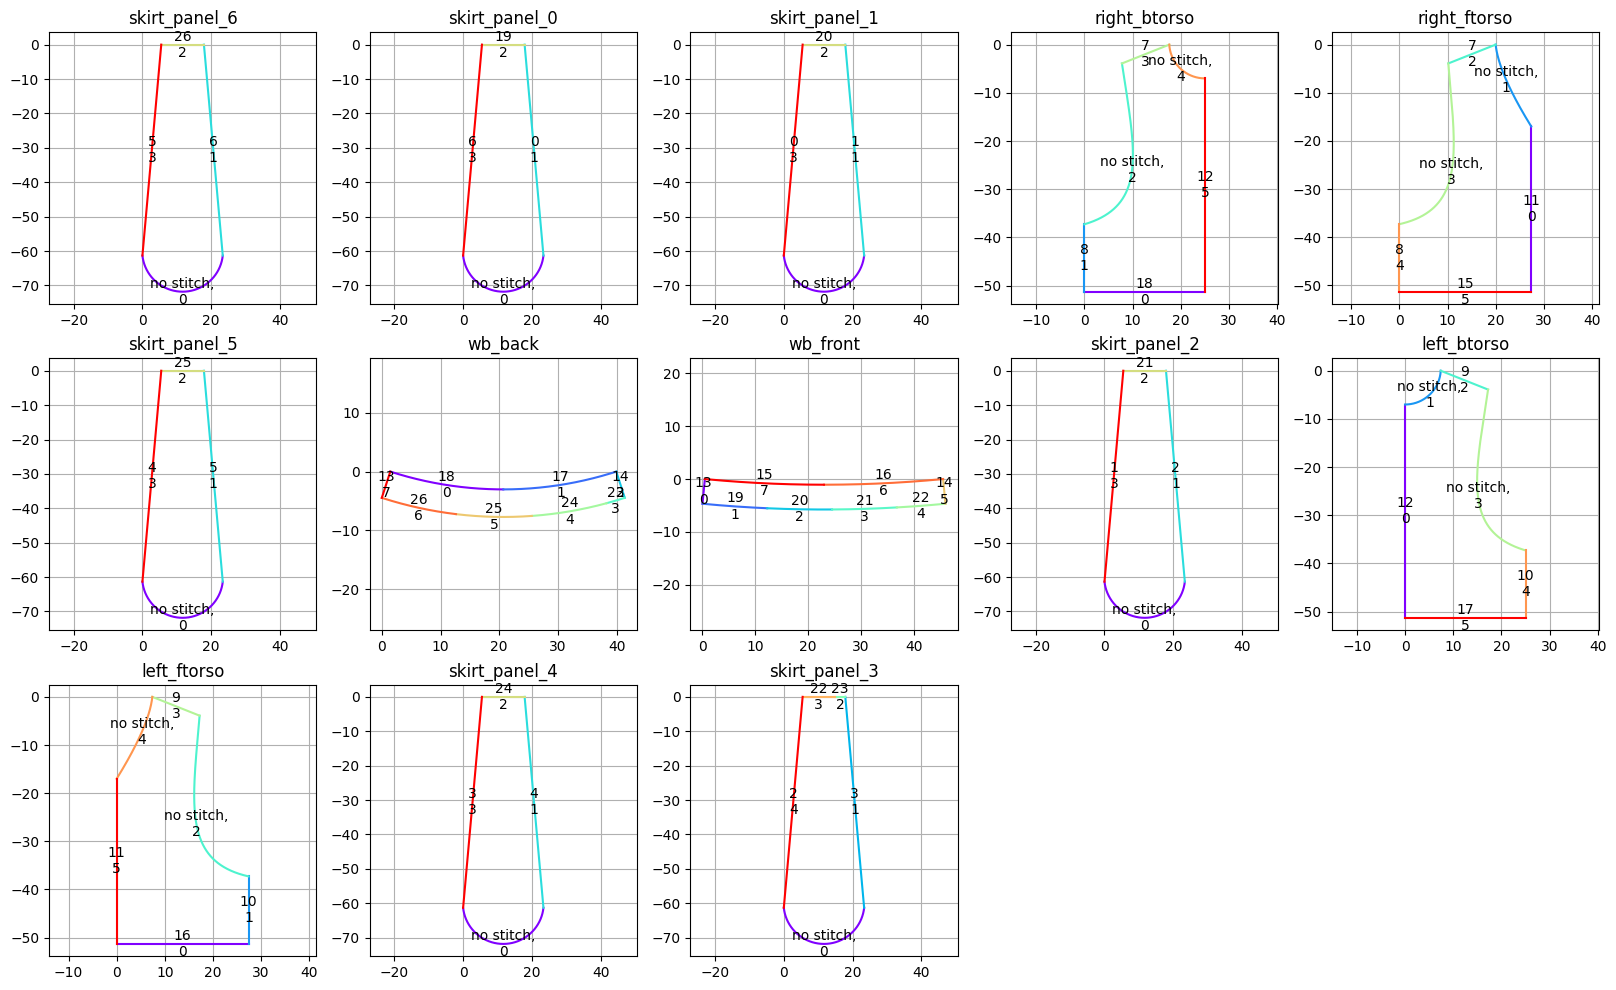

In [50]:
panel_svg_path_dict = {
    panel_name : pattern._draw_a_panel(
        panel_name, apply_transform=False, fill=True
    )
    for panel_name in pattern.panel_order() 
}
stitch_dict = {
    i : v for i, v in enumerate(pattern.pattern['stitches'])
}

FIGLEN = 4
NCOLS = int(np.sqrt(len(panel_svg_path_dict)))
NROWS = int(np.ceil(len(panel_svg_path_dict) / NCOLS))
NCOLS = 5
NROWS = 3

plt.figure(figsize=(FIGLEN * NCOLS, FIGLEN * NROWS))
for i, (panel_name, panel) in enumerate(panel_svg_path_dict.items()):
    ax = plt.subplot(NROWS, NCOLS, i + 1)
    ax.set_title(panel_name)
    plot_panel_info(
        ax, panel_name, panel_svg_path_dict, stitch_dict,
        N_SAMPLES=1000
    )
# plt.savefig(f"{garment_id}_panel_vis.png")
plt.show()

In [78]:
panel_svg_path_dict

{'skirt_panel_6': (Path(Arc(start=61.33357498201926j, radius=(11.745690574779847+11.745690574779847j), rotation=0, large_arc=False, sweep=False, end=(23.36159451337427+61.33357498201926j)),
       Line(start=(23.36159451337427+61.33357498201926j), end=(17.885186434527633+0j)),
       Line(start=(17.885186434527633+0j), end=(5.476408078846637+0j)),
       Line(start=(5.476408078846637+0j), end=61.33357498201926j)),
  {'fill': 'rgb(227,175,186)',
   'stroke': 'rgb(51,51,51)',
   'stroke-width': '0.2'},
  False),
 'skirt_panel_0': (Path(Arc(start=61.33357498201926j, radius=(11.745690574779847+11.745690574779847j), rotation=0, large_arc=False, sweep=False, end=(23.36159451337427+61.33357498201926j)),
       Line(start=(23.36159451337427+61.33357498201926j), end=(17.885186434527633+0j)),
       Line(start=(17.885186434527633+0j), end=(5.476408078846637+0j)),
       Line(start=(5.476408078846637+0j), end=61.33357498201926j)),
  {'fill': 'rgb(227,175,186)',
   'stroke': 'rgb(51,51,51)',
   's

In [34]:
#panel_svg_path_dict['left_ftorso']
print(stitch_dict[0][0]['panel']) # 여기서 stitch할 이름 
print(stitch_dict[0][0]['edge']) # 여기서 stitch할 엣지번호 찾음.

right_btorso
4


In [51]:
panel_svg_path_dict['skirt_panel_6']

(Path(Arc(start=61.33357498201926j, radius=(11.745690574779847+11.745690574779847j), rotation=0, large_arc=False, sweep=False, end=(23.36159451337427+61.33357498201926j)),
      Line(start=(23.36159451337427+61.33357498201926j), end=(17.885186434527633+0j)),
      Line(start=(17.885186434527633+0j), end=(5.476408078846637+0j)),
      Line(start=(5.476408078846637+0j), end=61.33357498201926j)),
 {'fill': 'rgb(227,175,186)',
  'stroke': 'rgb(51,51,51)',
  'stroke-width': '0.2'},
 False)

In [55]:
type_info = panel_svg_path_dict['skirt_panel_6'][0]
type_info

Path(Arc(start=61.33357498201926j, radius=(11.745690574779847+11.745690574779847j), rotation=0, large_arc=False, sweep=False, end=(23.36159451337427+61.33357498201926j)),
     Line(start=(23.36159451337427+61.33357498201926j), end=(17.885186434527633+0j)),
     Line(start=(17.885186434527633+0j), end=(5.476408078846637+0j)),
     Line(start=(5.476408078846637+0j), end=61.33357498201926j))

In [61]:
start_x, start_y = type_info[0].start.real, type_info[0].start.imag
end_x, end_y = type_info[0].end.real, type_info[0].end.imag
radius_x = type_info[0].radius.real
rotation_angle = type_info[0].rotation
large_arc = type_info[0].large_arc
sweep = type_info[0].sweep
print(start_x, start_y, end_x, end_y, radius_x, rotation_angle, large_arc, sweep)


0.0 61.33357498201926 23.36159451337427 61.33357498201926 11.745690574779847 0 False False


In [63]:
distance = (start_x- end_x)**2 + (start_y - end_y)**2
print(distance**0.5)

23.36159451337427


In [58]:
a = (start_x - radius_x)**2 + (start_y - radius_y)**2
b = (end_x - radius_x)**2 + (end_y - radius_y)**2
midle_point_x , midle_point_y = (start_x + end_x) / 2, (start_y + end_y) / 2
print(a, b)
print(midle_point_x, midle_point_y)


2596.9195270642103 2593.8875042963914
11.680797256687136 61.33357498201926


/home/hjp/anaconda3/envs/GarmentCode/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 46160 (\N{HANGUL SYLLABLE DU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjp/anaconda3/envs/GarmentCode/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 52968 (\N{HANGUL SYLLABLE KEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjp/anaconda3/envs/GarmentCode/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjp/anaconda3/envs/GarmentCode/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 47204 (\N{HANGUL SYLLABLE ROL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjp/anaconda3/envs/GarmentCode/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWar

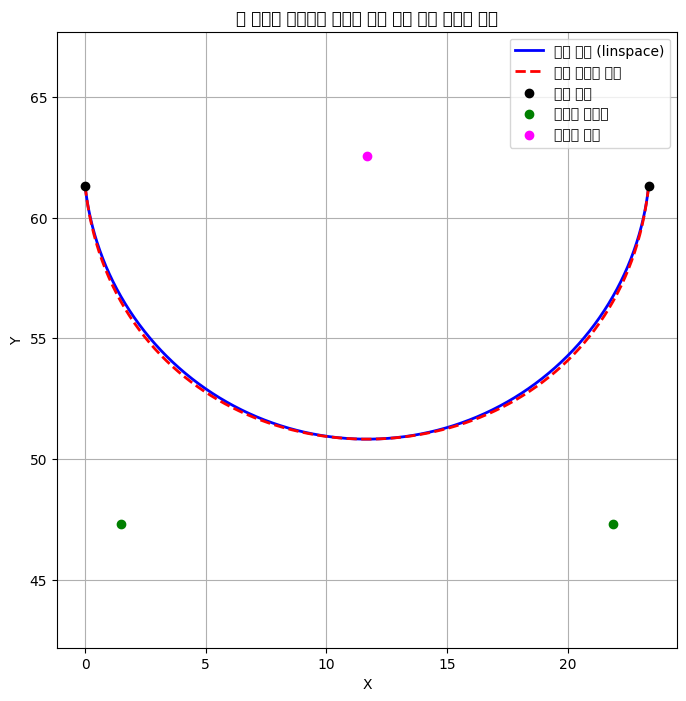

In [74]:
import math
import numpy as np
import matplotlib.pyplot as plt

# === 1. 원형 호 (Circular Arc) 위한 기본 파라미터 ===
# 두 끝점 (SVG endpoint 형식)
x1, y1 = 0.0, 61.33357498201926
x2, y2 = 23.36159451337427, 61.33357498201926

# 단일 반지름 r (rx 만 사용)
r = 11.745690574779847

# SVG 플래그
large_arc_flag = False   # 작은 호 vs 큰 호 (False: 작은 호)
sweep_flag = True  # 호의 진행 방향 (False: 시계 방향)

# === 2. 원의 중심 계산 (엔드포인트로부터) ===
# 두 점 사이의 거리
dx = x2 - x1
dy = y2 - y1
d = math.hypot(dx, dy)

# 만약 두 점 사이의 거리가 2r보다 크면, 주어진 r로는 호를 만들 수 없음
if d > 2 * r:
    print("경고: 두 점 사이의 거리가 2r보다 큽니다. r을 d/2로 조정합니다.")
    r = d / 2

# 두 점의 중간점
mid_x = (x1 + x2) / 2.0
mid_y = (y1 + y2) / 2.0

# 두 점을 잇는 선의 길이의 절반에 해당하는 값
half_d = d / 2.0

# 원의 중심까지의 수직 거리 (피타고라스)
h = math.sqrt(r**2 - half_d**2)

# 선분의 단위 벡터 (끝점 방향)
ux = dx / d
uy = dy / d

# 선분에 수직인 단위벡터 (두 후보가 있음)
# candidate1: (-uy, ux), candidate2: (uy, -ux)
# SVG 사양에서는 일반적으로 large_arc_flag와 sweep_flag의 관계에 따라 후보를 선택함
if large_arc_flag != sweep_flag:
    cx = mid_x + (-uy) * h
    cy = mid_y + (ux) * h
else:
    cx = mid_x + (uy) * h
    cy = mid_y + (-ux) * h

# === 3. 시작각과 끝각 (극각) 계산 ===
# 각도는 중심을 기준으로 atan2로 계산
theta_start = math.atan2(y1 - cy, x1 - cx)
theta_end   = math.atan2(y2 - cy, x2 - cx)

# SVG의 sweep_flag에 따라 호의 진행 방향을 결정
delta = theta_end - theta_start
if sweep_flag:
    if delta < 0:
        delta += 2 * math.pi
else:
    if delta > 0:
        delta -= 2 * math.pi
# (delta는 음수면 시계, 양수면 반시계 진행)

# === 4. 큐빅 베지어 곡선을 위한 컨트롤 포인트 계산 ===
# 원호를 근사하기 위한 상수 (kappa)
k = (4.0 / 3.0) * math.tan(delta / 4.0)
# (delta가 음수이면 k도 음수가 되어, 올바른 접선 방향을 제공)

# 끝점(호 위의) 좌표들 (원 위의 점)
P0 = (cx + r * math.cos(theta_start), cy + r * math.sin(theta_start))
P3 = (cx + r * math.cos(theta_end),   cy + r * math.sin(theta_end))

# 접선 방향은 원의 접선: 반지름에 대해 수직 방향
# - 반시계 진행(양의 delta)에서는 접선 = (-sin(theta), cos(theta))
# - 시계 진행(음의 delta)에서는 접선 = ( sin(theta), -cos(theta))
# (k가 delta의 부호를 반영하므로 아래 공식은 그대로 사용할 수 있음)
P1 = (P0[0] + k * r * (-math.sin(theta_start)),
      P0[1] + k * r * ( math.cos(theta_start)))
P2 = (P3[0] + k * r * ( math.sin(theta_end)),
      P3[1] + k * r * (-math.cos(theta_end)))

# === 5. 베지어 곡선 점들 계산 (평가) ===
def cubic_bezier(t, P0, P1, P2, P3):
    """매개변수 t (0~1)에 대해 큐빅 베지어 곡선의 점을 계산"""
    return ((1-t)**3 * np.array(P0) +
            3*(1-t)**2 * t * np.array(P1) +
            3*(1-t) * t**2 * np.array(P2) +
            t**3 * np.array(P3))

num_bezier = 100
t_vals = np.linspace(0, 1, num_bezier)
bezier_points = np.array([cubic_bezier(t, P0, P1, P2, P3) for t in t_vals])
bez_x, bez_y = bezier_points[:,0], bezier_points[:,1]

# === 6. 실제 원형 호의 점들 (참고용) 계산 ===
# true_arc: 극각 t를 theta_start부터 theta_start+delta까지 변화
num_arc = 100
arc_angles = np.linspace(theta_start, theta_start + delta, num_arc)
arc_x = cx + r * np.cos(arc_angles)
arc_y = cy + r * np.sin(arc_angles)

# === 7. 시각화 ===
plt.figure(figsize=(8, 8))
# 실제 원형 호
plt.plot(arc_x, arc_y, 'b-', lw=2, label="실제 원호 (linspace)")
# 큐빅 베지어 근사
plt.plot(bez_x, bez_y, 'r--', lw=2, label="큐빅 베지어 근사")
# 엔드포인트와 컨트롤 포인트 표시
plt.scatter([P0[0], P3[0]], [P0[1], P3[1]], color="black", zorder=5, label="호의 끝점")
plt.scatter([P1[0], P2[0]], [P1[1], P2[1]], color="green", zorder=5, label="컨트롤 포인트")
# 중심 표시
plt.scatter([cx], [cy], color="magenta", zorder=5, label="계산된 중심")

plt.title("두 컨트롤 포인트를 이용한 원형 호의 큐빅 베지어 근사")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.gca().set_aspect("equal", adjustable="datalim")
plt.show()

In [99]:
import json
TEST_PATH= "/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/GarmentCodeData_v2/garments_5000_24/default_body/rand_N6XBXWW3FN/rand_N6XBXWW3FN_specification.json"

with open(TEST_PATH, "r") as f:
    data = json.load(f)

print(data)

{'pattern': {'panels': {'skirt_panel_12': {'translation': [-17.400669479625957, 80.22550746923655, -22.511671124751583], 'rotation': [180.0, -44.26579582898515, -180.0], 'vertices': [[0, 0], [11.895642792348445, 0], [8.959742824745652, 19.54699253076346], [2.935899967602794, 19.54699253076346]], 'edges': [{'endpoints': [0, 1], 'curvature': {'type': 'circle', 'params': [7.434776745217778, 0, 0]}}, {'endpoints': [1, 2]}, {'endpoints': [2, 3]}, {'endpoints': [3, 0]}], 'label': 'leg'}, 'skirt_panel_5': {'translation': [17.400669479625943, 80.22550746923655, 27.51167112475159], 'rotation': [0.0, 44.26579582898515, 0.0], 'vertices': [[0, 0], [11.895642792348445, 0], [8.959742824745652, 19.54699253076346], [2.935899967602794, 19.54699253076346]], 'edges': [{'endpoints': [0, 1], 'curvature': {'type': 'circle', 'params': [7.434776745217778, 0, 0]}}, {'endpoints': [1, 2]}, {'endpoints': [2, 3]}, {'endpoints': [3, 0]}], 'label': 'leg'}, 'skirt_panel_2': {'translation': [-20.51256308576097, 80.225

=== Cubic Bezier Points ===
P0 (start) = (0.0, 521.3353873471636)
P1 (control1) = (12.576325046366929, 402.1912553289554)
P2 (control2) = (185.99722831731438, 402.1912553289554)
P3 (end) = (198.5735533636813, 521.3353873471636)

=== Center & Angles ===
Center = (99.28677668184065, 531.8156582191361)
theta_start = -3.0364265303679057, theta_end = -0.10516612322188766, delta_theta = 2.931260407146018


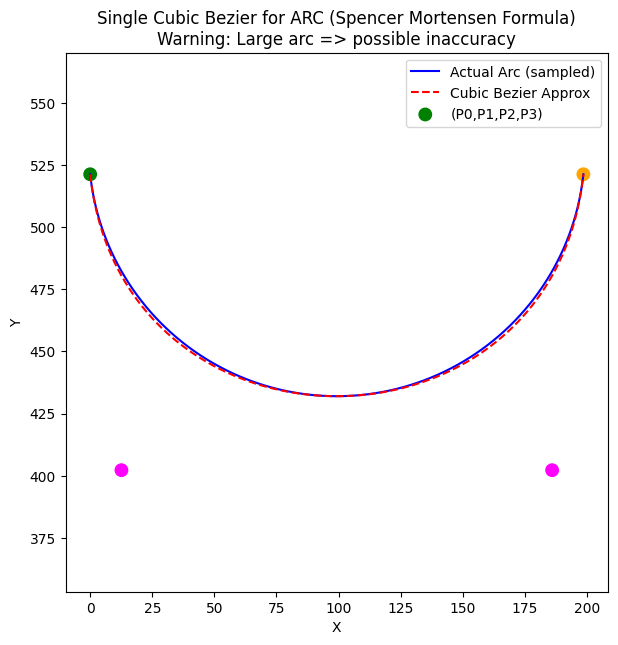


SVG Path Data:
M 0.0,521.3353873471636 C 12.576325046366929,402.1912553289554 185.99722831731438,402.1912553289554 198.5735533636813,521.3353873471636


In [108]:
#이게 된 최종본.
import math
import numpy as np
import matplotlib.pyplot as plt

def single_arc_to_cubic_bezier(x1, y1, x2, y2, r,
                               rotation_angle,
                               large_arc_flag,
                               sweep_flag):
    """
    하나의 Arc (SVG 파라미터) -> 하나의 Cubic Bezier (컨트롤포인트 2개) 근사.
    회전각 rotation_angle=0 으로 가정합니다.
    
    반환값: (P0, P1, P2, P3),  # Cubic Bezier 4개 점
           (cx, cy),          # 계산된 호의 중심
           (theta_start, theta_end, delta_theta) # 각도 정보
    """
    # 1) 시작점과 끝점
    dx = x2 - x1
    dy = y2 - y1
    d = math.hypot(dx, dy)

    # 만약 두 점 사이 거리가 2r보다 크면, 실제로는 호를 만들기 어려워서
    # SVG 사양에서는 반지름을 늘려 강제 조정하지만, 여기서는 간단히 처리
    if d > 2*r:
        r = d/2

    mid_x = (x1 + x2)/2.0
    mid_y = (y1 + y2)/2.0

    # 2) 중심 (cx, cy) 계산 (endpoint-to-center)
    # chord midpoint -> center distance
    h = math.sqrt(abs(r**2 - (d/2.0)**2))
    # 단위 방향벡터
    ux = dx / d
    uy = dy / d

    # SVG 사양: large_arc_flag != sweep_flag 이면 candidate1, 아니면 candidate2
    # candidate1: center = mid + (-uy, ux)*h
    # candidate2: center = mid + (uy, -ux)*h
    if large_arc_flag != sweep_flag:
        cx = mid_x + (-uy)*h
        cy = mid_y + (ux)*h
    else:
        cx = mid_x + (uy)*h
        cy = mid_y + (-ux)*h

    # 3) 시작각, 끝각
    theta_start = math.atan2(y1 - cy, x1 - cx)
    theta_end   = math.atan2(y2 - cy, x2 - cx)

    # 아크의 진행각
    delta_theta = theta_end - theta_start

    # sweep_flag 적용
    if sweep_flag:
        if delta_theta < 0:
            delta_theta += 2*math.pi
    else:
        if delta_theta > 0:
            delta_theta -= 2*math.pi

    # large_arc_flag 적용
    if large_arc_flag and abs(delta_theta) < math.pi:
        if delta_theta > 0:
            delta_theta -= 2*math.pi
        else:
            delta_theta += 2*math.pi
    elif not large_arc_flag and abs(delta_theta) > math.pi:
        if delta_theta > 0:
            delta_theta -= 2*math.pi
        else:
            delta_theta += 2*math.pi

    # 4) 하나의 Cubic Bezier로 근사 (Spencer Mortensen 공식)
    # P0, P3
    P0 = (cx + r*math.cos(theta_start), cy + r*math.sin(theta_start))
    P3 = (cx + r*math.cos(theta_start + delta_theta),
          cy + r*math.sin(theta_start + delta_theta))

    # k = 4/3 * tan((delta_theta)/4)
    k = (4.0/3.0) * math.tan(delta_theta/4.0)

    # P1, P2
    # P1 = P0 + k*r*(-sin(theta_start), cos(theta_start))
    P1 = (P0[0] - k*r*math.sin(theta_start),
          P0[1] + k*r*math.cos(theta_start))

    # P2 = P3 + k*r*(sin(theta_end), -cos(theta_end))
    # 끝각 = theta_start + delta_theta
    the_end = theta_start + delta_theta
    P2 = (P3[0] + k*r*math.sin(the_end),
          P3[1] - k*r*math.cos(the_end))

    return (P0, P1, P2, P3), (cx, cy), (theta_start, theta_end, delta_theta)

# --------------------------
# 질문에서 주어진 ARC 파라미터:
# start_x, start_y, end_x, end_y, radius_x, rotation_angle, large_arc, sweep
#   0.0 61.33357498201926  23.36159451337427 61.33357498201926
#   11.745690574779847
#   0
#   False
#   False
start_x = 0.0 * 8.5
start_y = 61.33357498201926 * 8.5
end_x   = 23.36159451337427 * 8.5
end_y   = 61.33357498201926 * 8.5
r_value = 11.745690574779847 * 8.5
rotation_angle = 0
large_arc_flag = False
sweep_flag     = True

# 단 하나의 Cubic Bézier로 근사
(P0, P1, P2, P3), (cx, cy), angles = single_arc_to_cubic_bezier(
    start_x, start_y,
    end_x,   end_y,
    r_value,
    rotation_angle,
    large_arc_flag,
    sweep_flag
)

print("=== Cubic Bezier Points ===")
print(f"P0 (start) = {P0}")
print(f"P1 (control1) = {P1}")
print(f"P2 (control2) = {P2}")
print(f"P3 (end) = {P3}")
print("")
print("=== Center & Angles ===")
print(f"Center = ({cx}, {cy})")
print(f"theta_start = {angles[0]}, theta_end = {angles[1]}, delta_theta = {angles[2]}")

# --------------------------
# 시각화 (옵션)
import matplotlib.pyplot as plt

# 실제 호(arc) 샘플링
theta_vals = np.linspace(angles[0], angles[0] + angles[2], 200)
arc_x = [cx + r_value*math.cos(t) for t in theta_vals]
arc_y = [cy + r_value*math.sin(t) for t in theta_vals]

# Bézier 곡선 샘플링
t_vals = np.linspace(0, 1, 100)
bezier_x = []
bezier_y = []
for t in t_vals:
    x = (1-t)**3*P0[0] + 3*(1-t)**2*t*P1[0] + 3*(1-t)*t**2*P2[0] + t**3*P3[0]
    y = (1-t)**3*P0[1] + 3*(1-t)**2*t*P1[1] + 3*(1-t)*t**2*P2[1] + t**3*P3[1]
    bezier_x.append(x)
    bezier_y.append(y)

plt.figure(figsize=(7,7))
plt.plot(arc_x, arc_y, 'b-', label="Actual Arc (sampled)")
plt.plot(bezier_x, bezier_y, 'r--', label="Cubic Bezier Approx")

plt.scatter([P0[0], P1[0], P2[0], P3[0]],
            [P0[1], P1[1], P2[1], P3[1]],
            color=['green','magenta','magenta','orange'],
            s=80, label="(P0,P1,P2,P3)")

plt.title("Single Cubic Bezier for ARC (Spencer Mortensen Formula)\nWarning: Large arc => possible inaccuracy")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.axis("equal")
plt.show()

# --------------------------
# SVG Path 생성 (하나의 세그먼트)
svg_path = f"M {P0[0]},{P0[1]} C {P1[0]},{P1[1]} {P2[0]},{P2[1]} {P3[0]},{P3[1]}"
print("\nSVG Path Data:")
print(svg_path)

/home/hjp/anaconda3/envs/GarmentCode/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjp/anaconda3/envs/GarmentCode/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjp/anaconda3/envs/GarmentCode/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjp/anaconda3/envs/GarmentCode/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjp/anaconda3/envs/GarmentCode/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWa

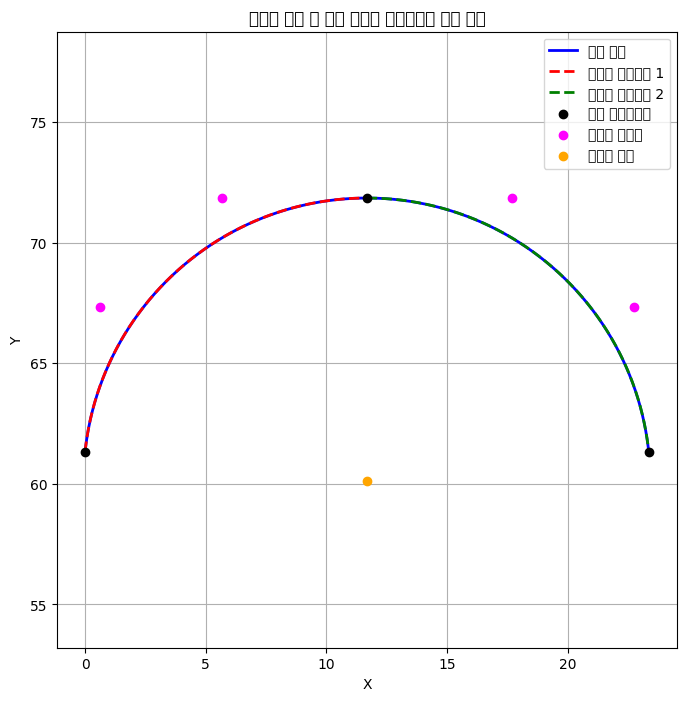

=== 세그먼트 1 ===
P0_seg1 = (0.0, 61.33357498201926)
P1_seg1 = (0.6308482004930757, 67.3100316182692)
P2_seg1 = (5.671138083569124, 71.84629251303764)
P3_seg1 = (11.680797256687136, 71.84629251303764)

=== 세그먼트 2 ===
P0_seg2 = (11.680797256687136, 71.84629251303764)
P1_seg2 = (17.690456429805145, 71.84629251303764)
P2_seg2 = (22.730746312881195, 67.3100316182692)
P3_seg2 = (23.36159451337427, 61.33357498201926)


In [79]:
import math
import numpy as np
import matplotlib.pyplot as plt

# === 기본 파라미터 (원형 아크용) ===
x1, y1 = 0.0, 61.33357498201926          # 시작점
x2, y2 = 23.36159451337427, 61.33357498201926  # 끝점
r = 11.745690574779847                    # 반지름 (하나의 값만 사용)
large_arc_flag = False                    # 큰 호 vs 작은 호
sweep_flag = False                        # 호의 진행 방향 (False: 시계, True: 반시계)

# === 1. 시작점과 끝점 사이의 거리 및 중간점 계산 ===
dx = x2 - x1
dy = y2 - y1
d = math.hypot(dx, dy)
if d > 2 * r:
    print("경고: 두 점 사이의 거리가 2r보다 큽니다. r을 d/2로 조정합니다.")
    r = d / 2
mid_x = (x1 + x2) / 2.0
mid_y = (y1 + y2) / 2.0

# === 2. 호의 중심 계산 (SVG 엔드포인트→중심 변환) ===
# 두 점을 잇는 선의 중간에서 원의 중심까지의 수직 거리 h
h = math.sqrt(r**2 - (d/2)**2)
ux = dx / d
uy = dy / d
# SVG 사양: if (large_arc_flag != sweep_flag) then candidate1, else candidate2
if large_arc_flag != sweep_flag:
    cx = mid_x + (-uy) * h
    cy = mid_y + (ux) * h
else:
    cx = mid_x + (uy) * h
    cy = mid_y + (-ux) * h

# === 3. 시작각과 끝각 (중심 기준) 계산 ===
theta_start = math.atan2(y1 - cy, x1 - cx)
theta_end   = math.atan2(y2 - cy, x2 - cx)

# === 4. 전체 호의 진행각 (delta_theta) 결정 ===
delta_theta = theta_end - theta_start
if sweep_flag:
    if delta_theta < 0:
        delta_theta += 2 * math.pi
else:
    if delta_theta > 0:
        delta_theta -= 2 * math.pi

if large_arc_flag and abs(delta_theta) < math.pi:
    if delta_theta > 0:
        delta_theta -= 2 * math.pi
    else:
        delta_theta += 2 * math.pi
elif not large_arc_flag and abs(delta_theta) > math.pi:
    if delta_theta > 0:
        delta_theta -= 2 * math.pi
    else:
        delta_theta += 2 * math.pi

# === 5. 호를 두 세그먼트로 분할 ===
# 중간각: 전체 호를 각도상에서 두 등분
theta_mid = theta_start + delta_theta / 2.0

# --- 세그먼트 1: 시작각 ~ 중간각 ---
delta1 = theta_mid - theta_start
k1 = (4.0 / 3.0) * math.tan(delta1 / 4.0)
P0_seg1 = (cx + r * math.cos(theta_start), cy + r * math.sin(theta_start))
P3_seg1 = (cx + r * math.cos(theta_mid),   cy + r * math.sin(theta_mid))
P1_seg1 = (P0_seg1[0] + k1 * r * (-math.sin(theta_start)),
           P0_seg1[1] + k1 * r * ( math.cos(theta_start)))
P2_seg1 = (P3_seg1[0] + k1 * r * ( math.sin(theta_mid)),
           P3_seg1[1] + k1 * r * (-math.cos(theta_mid)))

# --- 세그먼트 2: 중간각 ~ 끝각 ---
delta2 = theta_end - theta_mid
k2 = (4.0 / 3.0) * math.tan(delta2 / 4.0)
# 세그먼트 2의 시작점은 세그먼트 1의 끝점과 동일
P0_seg2 = P3_seg1
P3_seg2 = (cx + r * math.cos(theta_end), cy + r * math.sin(theta_end))
P1_seg2 = (P0_seg2[0] + k2 * r * (-math.sin(theta_mid)),
           P0_seg2[1] + k2 * r * ( math.cos(theta_mid)))
P2_seg2 = (P3_seg2[0] + k2 * r * ( math.sin(theta_end)),
           P3_seg2[1] + k2 * r * (-math.cos(theta_end)))

# === 6. 베지어 곡선 평가 함수 ===
def cubic_bezier(t, P0, P1, P2, P3):
    return ((1 - t)**3 * np.array(P0) +
            3 * (1 - t)**2 * t * np.array(P1) +
            3 * (1 - t) * t**2 * np.array(P2) +
            t**3 * np.array(P3))

num_pts = 100
t_vals = np.linspace(0, 1, num_pts)
bezier_seg1 = np.array([cubic_bezier(t, P0_seg1, P1_seg1, P2_seg1, P3_seg1) for t in t_vals])
bezier_seg2 = np.array([cubic_bezier(t, P0_seg2, P1_seg2, P2_seg2, P3_seg2) for t in t_vals])
bezier_full = np.vstack((bezier_seg1, bezier_seg2))

# === 7. 실제 원호 (참고용) 계산 ===
num_arc_pts = 200
arc_angles = np.linspace(theta_start, theta_start + delta_theta, num_arc_pts)
arc_x = cx + r * np.cos(arc_angles)
arc_y = cy + r * np.sin(arc_angles)

# === 8. 시각화 ===
plt.figure(figsize=(8,8))
# 실제 원호
plt.plot(arc_x, arc_y, 'b-', lw=2, label="실제 원호")
# 두 세그먼트의 베지어 곡선
plt.plot(bezier_seg1[:, 0], bezier_seg1[:, 1], 'r--', lw=2, label="베지어 세그먼트 1")
plt.plot(bezier_seg2[:, 0], bezier_seg2[:, 1], 'g--', lw=2, label="베지어 세그먼트 2")
# 엔드포인트 및 컨트롤 포인트 표시
plt.scatter([P0_seg1[0], P3_seg1[0], P3_seg2[0]],
            [P0_seg1[1], P3_seg1[1], P3_seg2[1]],
            color="black", zorder=5, label="호의 엔드포인트")
plt.scatter([P1_seg1[0], P2_seg1[0], P1_seg2[0], P2_seg2[0]],
            [P1_seg1[1], P2_seg1[1], P1_seg2[1], P2_seg2[1]],
            color="magenta", zorder=5, label="컨트롤 포인트")
plt.scatter([cx], [cy], color="orange", zorder=5, label="계산된 중심")
plt.title("중간점 기준 두 큐빅 베지어 세그먼트로 원호 근사")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)
plt.gca().set_aspect("equal", adjustable="datalim")
plt.show()

# === 9. 컨트롤 포인트 출력 ===
print("=== 세그먼트 1 ===")
print("P0_seg1 =", P0_seg1)
print("P1_seg1 =", P1_seg1)
print("P2_seg1 =", P2_seg1)
print("P3_seg1 =", P3_seg1)
print("\n=== 세그먼트 2 ===")
print("P0_seg2 =", P0_seg2)
print("P1_seg2 =", P1_seg2)
print("P2_seg2 =", P2_seg2)
print("P3_seg2 =", P3_seg2)

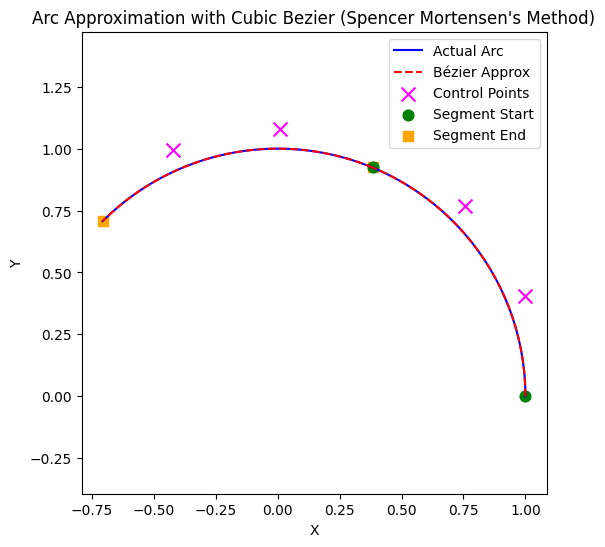

SVG Path data:
M 1.0,0.0 C 1.0,0.4044622448097899 0.7563578220184242,0.7690985324053872 0.38268343236508984,0.9238795325112867 C 0.009009042711755566,1.0786605326171863 -0.4211087851476115,0.9931047772254835 -0.7071067811865475,0.7071067811865476 


In [96]:
import math
import numpy as np
import matplotlib.pyplot as plt

def arc_to_bezier(cx, cy, r, theta_start, theta_end):
    """
    (cx, cy)를 중심으로 하는 원에서
    [theta_start, theta_end] 구간의 호(Arc)를
    여러 개의 Cubic Bezier 곡선 세그먼트로 근사하여 반환.

    - 반환값 segments는 리스트이며,
      각 원소는 (P0, P1, P2, P3) 형태의 4개 점 튜플.
    """
    # 전체 호의 각도
    total_angle = theta_end - theta_start
    # 세그먼트 하나당 최대 90도(π/2)로 제한
    num_segments = int(math.ceil(abs(total_angle) / (math.pi / 2.0)))
    # 각 세그먼트 각도
    delta = total_angle / num_segments

    segments = []
    for i in range(num_segments):
        # 현재 세그먼트의 시작각, 끝각
        t0 = theta_start + i * delta
        t1 = t0 + delta

        # 세그먼트의 엔드포인트: P0, P3
        P0 = (cx + r * math.cos(t0), cy + r * math.sin(t0))
        P3 = (cx + r * math.cos(t1), cy + r * math.sin(t1))

        # 호의 각도
        seg_angle = t1 - t0
        # k = 4/3 * tan((각도)/4)
        k = (4.0 / 3.0) * math.tan(seg_angle / 4.0)

        # 컨트롤 포인트 계산
        # P1 = P0 + k*r*(-sin(t0), cos(t0))
        P1 = (P0[0] - k * r * math.sin(t0),
              P0[1] + k * r * math.cos(t0))
        # P2 = P3 + k*r*(sin(t1), -cos(t1))
        P2 = (P3[0] + k * r * math.sin(t1),
              P3[1] - k * r * math.cos(t1))

        segments.append((P0, P1, P2, P3))

    return segments

# ---------------------
# 예시: 원의 중심(0,0), 반지름=1, 호의 시작각=0(0도), 끝각=3π/4(135도)
cx, cy = 0.0, 0.0
r = 1.0
theta_start = 0.0        # 라디안(0도)
theta_end   = 3.0*math.pi/4.0  # 라디안(135도)

bezier_segments = arc_to_bezier(cx, cy, r, theta_start, theta_end)

# 시각화
plt.figure(figsize=(6,6))

# 실제 원호
theta_vals = np.linspace(theta_start, theta_end, 200)
arc_x = cx + r * np.cos(theta_vals)
arc_y = cy + r * np.sin(theta_vals)
plt.plot(arc_x, arc_y, 'b-', label="Actual Arc")

# 베지어 세그먼트 시각화
for i, (P0, P1, P2, P3) in enumerate(bezier_segments):
    # Bézier 곡선 점들 샘플링
    t_sample = np.linspace(0, 1, 50)
    bx = []
    by = []
    for t in t_sample:
        x = (1-t)**3*P0[0] + 3*(1-t)**2*t*P1[0] + 3*(1-t)*t**2*P2[0] + t**3*P3[0]
        y = (1-t)**3*P0[1] + 3*(1-t)**2*t*P1[1] + 3*(1-t)*t**2*P2[1] + t**3*P3[1]
        bx.append(x)
        by.append(y)
    plt.plot(bx, by, 'r--', label="Bézier Approx" if i==0 else None)

    # 컨트롤 포인트 시각화 (P1, P2)
    plt.scatter([P1[0], P2[0]], [P1[1], P2[1]],
                color='magenta', marker='x', s=100,
                label="Control Points" if i==0 else None)
    # 엔드포인트 시각화 (P0, P3)
    plt.scatter(P0[0], P0[1], color='green', marker='o', s=60, label="Segment Start" if i==0 else None)
    plt.scatter(P3[0], P3[1], color='orange', marker='s', s=60, label="Segment End" if i==0 else None)

plt.gca().set_aspect("equal", adjustable="datalim")
plt.legend()
plt.title("Arc Approximation with Cubic Bezier (Spencer Mortensen's Method)")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

# SVG Path로 변환
svg_path = ""
if bezier_segments:
    # 첫 세그먼트
    P0, P1, P2, P3 = bezier_segments[0]
    svg_path += f"M {P0[0]},{P0[1]} C {P1[0]},{P1[1]} {P2[0]},{P2[1]} {P3[0]},{P3[1]} "
    for seg in bezier_segments[1:]:
        _, cp1, cp2, p_end = seg
        svg_path += f"C {cp1[0]},{cp1[1]} {cp2[0]},{cp2[1]} {p_end[0]},{p_end[1]} "

print("SVG Path data:")
print(svg_path)

10
전체 점 (flat_points):
P0: (0.000000, 61.333575)
P1: (0.120688, 62.476938)
P2: (0.408593, 63.596386)
P3: (0.854504, 64.656106)
P4: (1.300415, 65.715827)
P5: (1.899500, 66.704336)
P6: (2.632593, 67.590010)
P7: (3.365686, 68.475685)
P8: (4.224843, 69.248926)
P9: (5.182578, 69.884997)
P10: (6.140314, 70.521069)
P11: (7.186249, 71.013078)
P12: (8.286923, 71.345284)
P13: (9.387597, 71.677489)
P14: (10.531083, 71.846293)
P15: (11.680797, 71.846293)
P16: (12.830512, 71.846293)
P17: (13.973997, 71.677489)
P18: (15.074671, 71.345284)
P19: (16.175345, 71.013078)
P20: (17.221281, 70.521069)
P21: (18.179016, 69.884997)
P22: (19.136752, 69.248926)
P23: (19.995909, 68.475685)
P24: (20.729002, 67.590010)
P25: (21.462095, 66.704336)
P26: (22.061180, 65.715827)
P27: (22.507091, 64.656106)
P28: (22.953001, 63.596386)
P29: (23.240906, 62.476938)
P30: (23.361595, 61.333575)

SVG Path 데이터:
M 0.0,61.33357498201926 C 0.12068828552111491,62.47693768695609 0.40859315833153675,63.59638593913511 0.85450398104577

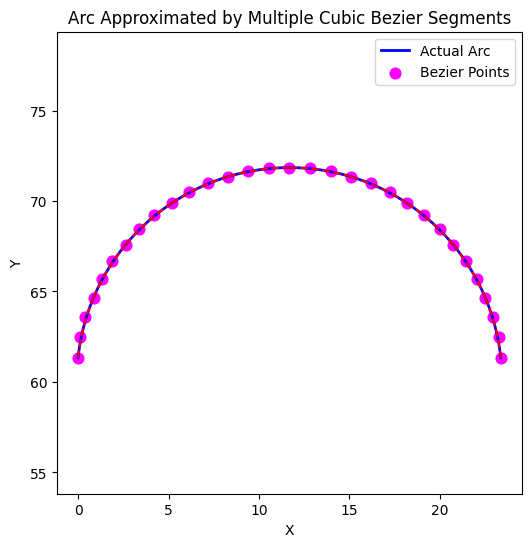

In [91]:
import math
import numpy as np
import matplotlib.pyplot as plt

def arc_to_bezier_flat_points(x1, y1, x2, y2, r, large_arc_flag, sweep_flag):
    """
    주어진 ARC 데이터(시작점, 끝점, 반지름, large_arc_flag, sweep_flag)를 이용하여
    Cubic Bezier 세그먼트들로 분할한 후, 
    전체 곡선을 구성하는 점들의 리스트(flat_points)를 반환합니다.
    
    flat_points의 구성은 다음과 같습니다.
      [P0, CP1, CP2, semiEnd1, CP3, CP4, semiEnd2, ... , End]
    여기서 첫 세그먼트는 [P0, CP1, CP2, semiEnd1],
    이후 각 세그먼트에서는 시작점은 이전 세그먼트의 semiEnd(즉, P3)와 동일하므로 
    두 개의 컨트롤 포인트와 최종 엔드포인트만 추가됩니다.
    
    또한, 세그먼트별로 (P0, P1, P2, P3)도 함께 반환합니다.
    """
    # 1. 시작점과 끝점 사이의 거리 및 중간점
    dx = x2 - x1
    dy = y2 - y1
    d = math.hypot(dx, dy)
    if d > 2 * r:
        # 원호를 만들 수 없으므로, r을 d/2로 조정 (SVG 사양 참고)
        r = d / 2
    mid_x = (x1 + x2) / 2.0
    mid_y = (y1 + y2) / 2.0
    
    # 2. SVG endpoint-to-center 변환 (회전각은 0로 가정)
    h = math.sqrt(abs(r**2 - (d/2)**2))
    ux = dx / d
    uy = dy / d
    # SVG 사양에 따라 두 후보중 선택:
    if large_arc_flag != sweep_flag:
        cx = mid_x + (-uy) * h
        cy = mid_y + (ux) * h
    else:
        cx = mid_x + (uy) * h
        cy = mid_y + (-ux) * h

    # 3. 중심 기준 시작각, 끝각 계산 (atan2)
    theta_start = math.atan2(y1 - cy, x1 - cx)
    theta_end   = math.atan2(y2 - cy, x2 - cx)
    
    # 4. 아크의 진행각 delta_theta 결정 (sweep_flag에 따라 조정)
    delta_theta = theta_end - theta_start
    if sweep_flag:
        if delta_theta < 0:
            delta_theta += 2 * math.pi
    else:
        if delta_theta > 0:
            delta_theta -= 2 * math.pi

    # large_arc_flag 보정
    if large_arc_flag and abs(delta_theta) < math.pi:
        if delta_theta > 0:
            delta_theta -= 2 * math.pi
        else:
            delta_theta += 2 * math.pi
    elif not large_arc_flag and abs(delta_theta) > math.pi:
        if delta_theta > 0:
            delta_theta -= 2 * math.pi
        else:
            delta_theta += 2 * math.pi

    # 5. 세그먼트 분할: 한 세그먼트의 최대 각도를 π/2 (90°)로 제한
    num_segments = 10#int(math.ceil(abs(delta_theta) / (math.pi/2)))
    print(num_segments)
    delta = delta_theta / num_segments  # 각 세그먼트의 각도

    segments = []  # 각 세그먼트별 (P0, P1, P2, P3)
    for i in range(num_segments):
        theta0 = theta_start + i * delta
        theta1 = theta0 + delta
        # 원 위의 엔드포인트들
        P0 = (cx + r * math.cos(theta0), cy + r * math.sin(theta0))
        P3 = (cx + r * math.cos(theta1), cy + r * math.sin(theta1))
        # 표준 근사 공식: k = 4/3 * tan( (theta1 - theta0) / 4 )
        k = (4.0 / 3.0) * math.tan((theta1 - theta0) / 4.0)
        # 컨트롤 포인트는 원의 접선 방향
        P1 = (P0[0] - k * r * math.sin(theta0),
              P0[1] + k * r * math.cos(theta0))
        P2 = (P3[0] + k * r * math.sin(theta1),
              P3[1] - k * r * math.cos(theta1))
        segments.append((P0, P1, P2, P3))
    
    # 6. flat_points 구성
    flat_points = []
    if segments:
        # 첫 세그먼트: 모든 4점 추가
        flat_points.extend(segments[0])
        # 이후 각 세그먼트: 추가할 점은 CP1, CP2, 그리고 엔드포인트 (P3)
        for seg in segments[1:]:
            flat_points.extend(seg[1:])  # seg[1], seg[2], seg[3]
    return flat_points, segments, (cx, cy), (theta_start, theta_end, delta_theta)

# 예제 ARC 데이터 (원형 아크로 가정)
start_x, start_y = 0.0, 61.33357498201926
end_x,   end_y   = 23.36159451337427, 61.33357498201926
r_value = 11.745690574779847
large_arc_flag = False
sweep_flag = False

# 계산
flat_points, segments, center, angles = arc_to_bezier_flat_points(start_x, start_y, end_x, end_y, r_value, large_arc_flag, sweep_flag)

# flat_points에는 아래와 같은 순서로 점들이 들어 있습니다.
# [start, CP1 (seg1), CP2 (seg1), semiEnd1, CP1 (seg2), CP2 (seg2), semiEnd2, ..., end]
print("전체 점 (flat_points):")
for i, pt in enumerate(flat_points):
    print(f"P{i}: ({pt[0]:.6f}, {pt[1]:.6f})")

# --- SVG Path 문자열 생성 ---
# 각 세그먼트 별로 "M" 및 "C" 명령어로 표현 (연속된 베지어 곡선)
svg_path = ""
if segments:
    # 첫 세그먼트: 시작점 M, 이어서 C
    P0, P1, P2, P3 = segments[0]
    svg_path += f"M {P0[0]},{P0[1]} C {P1[0]},{P1[1]} {P2[0]},{P2[1]} {P3[0]},{P3[1]} "
    for seg in segments[1:]:
        _, cp1, cp2, p_end = seg
        svg_path += f"C {cp1[0]},{cp1[1]} {cp2[0]},{cp2[1]} {p_end[0]},{p_end[1]} "
print("\nSVG Path 데이터:")
print(svg_path)

# --- 시각화 (옵션) ---
plt.figure(figsize=(6,6))
# 실제 원호: 촘촘한 샘플링 (계산된 중심, 반지름, 전체 각도)
num_arc_pts = 200
theta_vals = np.linspace(angles[0], angles[0] + angles[2], num_arc_pts)
arc_x = center[0] + r_value * np.cos(theta_vals)
arc_y = center[1] + r_value * np.sin(theta_vals)
plt.plot(arc_x, arc_y, 'b-', lw=2, label="Actual Arc")

# 각 Cubic Bezier 세그먼트 그리기
for seg in segments:
    P0, P1, P2, P3 = seg
    t_vals = np.linspace(0, 1, 50)
    bezier_pts = []
    for t in t_vals:
        x = ((1-t)**3)*P0[0] + 3*((1-t)**2)*t*P1[0] + 3*(1-t)*(t**2)*P2[0] + (t**3)*P3[0]
        y = ((1-t)**3)*P0[1] + 3*((1-t)**2)*t*P1[1] + 3*(1-t)*(t**2)*P2[1] + (t**3)*P3[1]
        bezier_pts.append((x,y))
    bezier_pts = np.array(bezier_pts)
    plt.plot(bezier_pts[:,0], bezier_pts[:,1], 'r--')
    
# 각 flat point (제어점 및 엔드포인트) 표시
flat_points_arr = np.array(flat_points)
plt.scatter(flat_points_arr[:,0], flat_points_arr[:,1], color='magenta', s=60, label="Bezier Points")
plt.legend()
plt.title("Arc Approximated by Multiple Cubic Bezier Segments")
plt.xlabel("X")
plt.ylabel("Y")
plt.gca().set_aspect("equal", adjustable="datalim")
plt.show()

전체 점 (flat_points):
P0: (0.000000, 61.333575)
P1: (0.120688, 62.476938)
P2: (0.408593, 63.596386)
P3: (0.854504, 64.656106)
P4: (1.300415, 65.715827)
P5: (1.899500, 66.704336)
P6: (2.632593, 67.590010)
P7: (3.365686, 68.475685)
P8: (4.224843, 69.248926)
P9: (5.182578, 69.884997)
P10: (6.140314, 70.521069)
P11: (7.186249, 71.013078)
P12: (8.286923, 71.345284)
P13: (9.387597, 71.677489)
P14: (10.531083, 71.846293)
P15: (11.680797, 71.846293)
P16: (12.830512, 71.846293)
P17: (13.973997, 71.677489)
P18: (15.074671, 71.345284)
P19: (16.175345, 71.013078)
P20: (17.221281, 70.521069)
P21: (18.179016, 69.884997)
P22: (19.136752, 69.248926)
P23: (19.995909, 68.475685)
P24: (20.729002, 67.590010)
P25: (21.462095, 66.704336)
P26: (22.061180, 65.715827)
P27: (22.507091, 64.656106)
P28: (22.953001, 63.596386)
P29: (23.240906, 62.476938)
P30: (23.361595, 61.333575)

SVG Path 데이터:
M 0.0,61.33357498201926 C 0.12068828552111491,62.47693768695609 0.40859315833153675,63.59638593913511 0.8545039810457755,

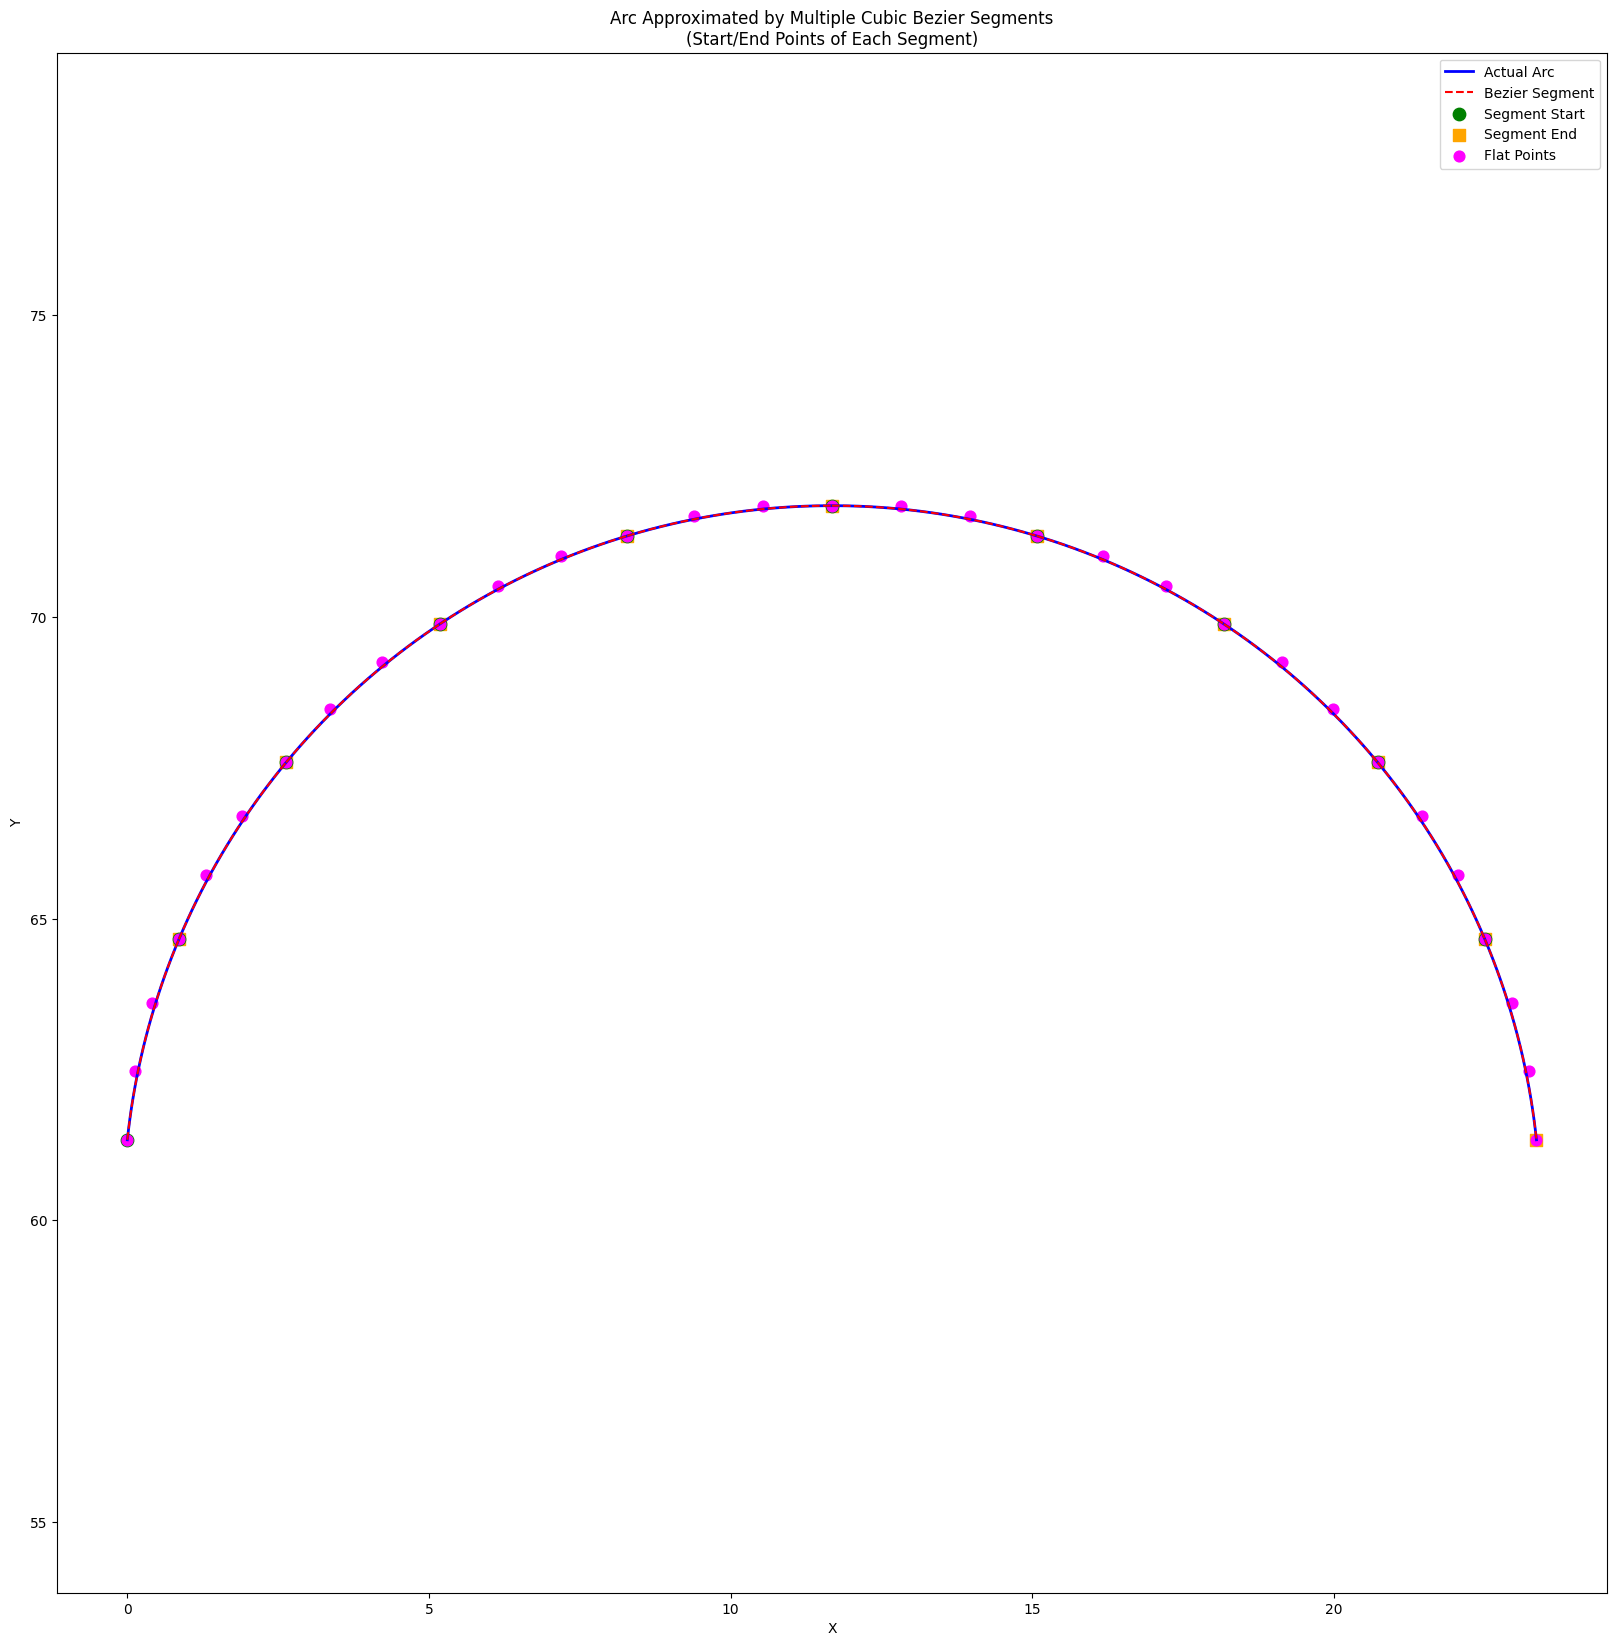

In [95]:
import math
import numpy as np
import matplotlib.pyplot as plt

def arc_to_bezier_flat_points(x1, y1, x2, y2, r, large_arc_flag, sweep_flag):
    """
    주어진 ARC 데이터(시작점, 끝점, 반지름, large_arc_flag, sweep_flag)를 이용하여
    Cubic Bezier 세그먼트들로 분할한 후, 
    전체 곡선을 구성하는 점들의 리스트(flat_points)를 반환합니다.
    
    flat_points의 구성은 다음과 같습니다.
      [P0, CP1, CP2, semiEnd1, CP1 (seg2), CP2 (seg2), semiEnd2, ... , End]
    또한, 세그먼트별 (P0, P1, P2, P3)도 함께 반환합니다.
    """
    # 1. 시작점과 끝점 사이의 거리 및 중간점
    dx = x2 - x1
    dy = y2 - y1
    d = math.hypot(dx, dy)
    if d > 2 * r:
        # 원호를 만들 수 없으므로, r을 d/2로 조정 (SVG 사양 참고)
        r = d / 2
    mid_x = (x1 + x2) / 2.0
    mid_y = (y1 + y2) / 2.0
    
    # 2. SVG endpoint-to-center 변환 (회전각은 0로 가정)
    h = math.sqrt(abs(r**2 - (d/2)**2))
    ux = dx / d
    uy = dy / d
    if large_arc_flag != sweep_flag:
        cx = mid_x + (-uy) * h
        cy = mid_y + (ux) * h
    else:
        cx = mid_x + (uy) * h
        cy = mid_y + (-ux) * h

    # 3. 중심 기준 시작각, 끝각 계산 (atan2)
    theta_start = math.atan2(y1 - cy, x1 - cx)
    theta_end   = math.atan2(y2 - cy, x2 - cx)
    
    # 4. 아크의 진행각 delta_theta 결정 (sweep_flag에 따라 조정)
    delta_theta = theta_end - theta_start
    if sweep_flag:
        if delta_theta < 0:
            delta_theta += 2 * math.pi
    else:
        if delta_theta > 0:
            delta_theta -= 2 * math.pi

    # large_arc_flag 보정
    if large_arc_flag and abs(delta_theta) < math.pi:
        if delta_theta > 0:
            delta_theta -= 2 * math.pi
        else:
            delta_theta += 2 * math.pi
    elif not large_arc_flag and abs(delta_theta) > math.pi:
        if delta_theta > 0:
            delta_theta -= 2 * math.pi
        else:
            delta_theta += 2 * math.pi

    # 5. 세그먼트 분할: 한 세그먼트의 최대 각도를 π/2 (90°)로 제한
    num_segments = 10  # 여기서는 임의로 10 세그먼트로 분할 (원하는 분할 개수로 조정 가능)
    delta = delta_theta / num_segments  # 각 세그먼트의 각도

    segments = []  # 각 세그먼트별 (P0, P1, P2, P3)
    for i in range(num_segments):
        theta0 = theta_start + i * delta
        theta1 = theta0 + delta
        # 원 위의 엔드포인트들
        P0 = (cx + r * math.cos(theta0), cy + r * math.sin(theta0))
        P3 = (cx + r * math.cos(theta1), cy + r * math.sin(theta1))
        # 표준 근사 공식: k = 4/3 * tan((theta1 - theta0) / 4)
        k = (4.0 / 3.0) * math.tan((theta1 - theta0) / 4.0)
        # 컨트롤 포인트는 원의 접선 방향
        P1 = (P0[0] - k * r * math.sin(theta0),
              P0[1] + k * r * math.cos(theta0))
        P2 = (P3[0] + k * r * math.sin(theta1),
              P3[1] - k * r * math.cos(theta1))
        segments.append((P0, P1, P2, P3))
    
    # 6. flat_points 구성
    flat_points = []
    if segments:
        # 첫 세그먼트: 모든 4점 추가
        flat_points.extend(segments[0])
        # 이후 각 세그먼트: 추가할 점은 CP1, CP2, 그리고 엔드포인트 (P3)
        for seg in segments[1:]:
            flat_points.extend(seg[1:])  # seg[1], seg[2], seg[3]
    return flat_points, segments, (cx, cy), (theta_start, theta_end, delta_theta)

# 예제 ARC 데이터 (원형 아크로 가정)
start_x, start_y = 0.0, 61.33357498201926
end_x,   end_y   = 23.36159451337427, 61.33357498201926
r_value = 11.745690574779847
large_arc_flag = False
sweep_flag = False

# 계산
flat_points, segments, center, angles = arc_to_bezier_flat_points(start_x, start_y, end_x, end_y, r_value, large_arc_flag, sweep_flag)

# flat_points에는 [P0, CP1, CP2, semiEnd1, CP1 (seg2), CP2 (seg2), semiEnd2, ... , End]가 들어 있습니다.
print("전체 점 (flat_points):")
for i, pt in enumerate(flat_points):
    print(f"P{i}: ({pt[0]:.6f}, {pt[1]:.6f})")

# SVG Path 문자열 생성
svg_path = ""
if segments:
    # 첫 세그먼트: 시작점 M, 이어서 C
    P0, P1, P2, P3 = segments[0]
    svg_path += f"M {P0[0]},{P0[1]} C {P1[0]},{P1[1]} {P2[0]},{P2[1]} {P3[0]},{P3[1]} "
    for seg in segments[1:]:
        _, cp1, cp2, p_end = seg
        svg_path += f"C {cp1[0]},{cp1[1]} {cp2[0]},{cp2[1]} {p_end[0]},{p_end[1]} "
print("\nSVG Path 데이터:")
print(svg_path)

# 시각화
plt.figure(figsize=(20,20))

# 실제 원호: 촘촘한 샘플링 (계산된 중심, 반지름, 전체 각도)
num_arc_pts = 200
theta_vals = np.linspace(angles[0], angles[0] + angles[2], num_arc_pts)
arc_x = center[0] + r_value * np.cos(theta_vals)
arc_y = center[1] + r_value * np.sin(theta_vals)
plt.plot(arc_x, arc_y, 'b-', lw=2, label="Actual Arc")

# 각 Cubic Bezier 세그먼트 그리기 및 시작/끝 점 표시
for i, seg in enumerate(segments):
    P0, P1, P2, P3 = seg
    t_vals = np.linspace(0, 1, 50)
    bezier_pts = []
    for t in t_vals:
        x = ((1-t)**3)*P0[0] + 3*((1-t)**2)*t*P1[0] + 3*(1-t)*(t**2)*P2[0] + (t**3)*P3[0]
        y = ((1-t)**3)*P0[1] + 3*((1-t)**2)*t*P1[1] + 3*(1-t)*(t**2)*P2[1] + (t**3)*P3[1]
        bezier_pts.append((x, y))
    bezier_pts = np.array(bezier_pts)
    plt.plot(bezier_pts[:,0], bezier_pts[:,1], 'r--', label="Bezier Segment" if i==0 else None)
    
    # 시작점 (P0)와 끝점 (P3) 각각 표시 (다른 색상과 마커로)
    plt.scatter(P0[0], P0[1], color='green', s=80, marker='o', label="Segment Start" if i==0 else None)
    plt.scatter(P3[0], P3[1], color='orange', s=80, marker='s', label="Segment End" if i==0 else None)

# flat_points (전체 제어/엔드 포인트) 표시
flat_points_arr = np.array(flat_points)
plt.scatter(flat_points_arr[:,0], flat_points_arr[:,1], color='magenta', s=60, label="Flat Points")

plt.legend()
plt.title("Arc Approximated by Multiple Cubic Bezier Segments\n(Start/End Points of Each Segment)")
plt.xlabel("X")
plt.ylabel("Y")
plt.gca().set_aspect("equal", adjustable="datalim")
plt.show()

전체 flat_points (겹치는 점 제거):
P0: (0.000000, 61.333575)
P1: (0.120688, 62.476938)
P2: (0.408593, 63.596386)
P3: (0.854504, 64.656106)
P4: (1.300415, 65.715827)
P5: (1.899500, 66.704336)
P6: (2.632593, 67.590010)
P7: (3.365686, 68.475685)
P8: (4.224843, 69.248926)
P9: (5.182578, 69.884997)
P10: (6.140314, 70.521069)
P11: (7.186249, 71.013078)
P12: (8.286923, 71.345284)
P13: (9.387597, 71.677489)
P14: (10.531083, 71.846293)
P15: (11.680797, 71.846293)
P16: (12.830512, 71.846293)
P17: (13.973997, 71.677489)
P18: (15.074671, 71.345284)
P19: (16.175345, 71.013078)
P20: (17.221281, 70.521069)
P21: (18.179016, 69.884997)
P22: (19.136752, 69.248926)
P23: (19.995909, 68.475685)
P24: (20.729002, 67.590010)
P25: (21.462095, 66.704336)
P26: (22.061180, 65.715827)
P27: (22.507091, 64.656106)
P28: (22.953001, 63.596386)
P29: (23.240906, 62.476938)
P30: (23.361595, 61.333575)

SVG Path 데이터:
M 0.0,61.33357498201926 C 0.12068828552111491,62.47693768695609 0.40859315833153675,63.59638593913511 0.8545039810

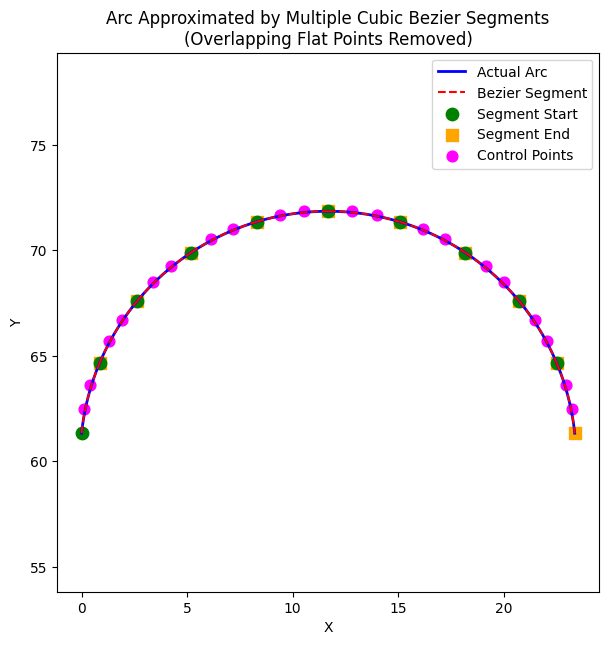

In [94]:
import math
import numpy as np
import matplotlib.pyplot as plt

def arc_to_bezier_flat_points(x1, y1, x2, y2, r, large_arc_flag, sweep_flag):
    """
    주어진 ARC 데이터(시작점, 끝점, 반지름, large_arc_flag, sweep_flag)를 이용하여
    Cubic Bezier 세그먼트들로 분할한 후, 
    전체 곡선을 구성하는 점들의 리스트(flat_points)를 반환합니다.
    
    flat_points의 구성은 다음과 같습니다.
      [P0, CP1, CP2, semiEnd1, CP1 (seg2), CP2 (seg2), semiEnd2, ... , End]
    또한, 세그먼트별 (P0, P1, P2, P3)도 함께 반환합니다.
    """
    # 1. 시작점과 끝점 사이의 거리 및 중간점 계산
    dx = x2 - x1
    dy = y2 - y1
    d = math.hypot(dx, dy)
    if d > 2 * r:
        # 원호를 만들 수 없으므로, r을 d/2로 조정 (SVG 사양 참고)
        r = d / 2
    mid_x = (x1 + x2) / 2.0
    mid_y = (y1 + y2) / 2.0
    
    # 2. SVG endpoint-to-center 변환 (회전각은 0로 가정)
    h = math.sqrt(abs(r**2 - (d/2)**2))
    ux = dx / d
    uy = dy / d
    if large_arc_flag != sweep_flag:
        cx = mid_x + (-uy) * h
        cy = mid_y + (ux) * h
    else:
        cx = mid_x + (uy) * h
        cy = mid_y + (-ux) * h

    # 3. 중심 기준 시작각, 끝각 계산 (atan2)
    theta_start = math.atan2(y1 - cy, x1 - cx)
    theta_end   = math.atan2(y2 - cy, x2 - cx)
    
    # 4. 아크의 진행각 delta_theta 결정 (sweep_flag에 따라 조정)
    delta_theta = theta_end - theta_start
    if sweep_flag:
        if delta_theta < 0:
            delta_theta += 2 * math.pi
    else:
        if delta_theta > 0:
            delta_theta -= 2 * math.pi

    # large_arc_flag 보정
    if large_arc_flag and abs(delta_theta) < math.pi:
        if delta_theta > 0:
            delta_theta -= 2 * math.pi
        else:
            delta_theta += 2 * math.pi
    elif not large_arc_flag and abs(delta_theta) > math.pi:
        if delta_theta > 0:
            delta_theta -= 2 * math.pi
        else:
            delta_theta += 2 * math.pi

    # 5. 세그먼트 분할: 한 세그먼트의 최대 각도를 π/2 (90°)로 제한
    num_segments = 10  # 여기서는 임의로 10 세그먼트로 분할 (원하는 분할 개수로 조정 가능)
    delta = delta_theta / num_segments  # 각 세그먼트의 각도

    segments = []  # 각 세그먼트별 (P0, P1, P2, P3)
    for i in range(num_segments):
        theta0 = theta_start + i * delta
        theta1 = theta0 + delta
        # 원 위의 엔드포인트들
        P0 = (cx + r * math.cos(theta0), cy + r * math.sin(theta0))
        P3 = (cx + r * math.cos(theta1), cy + r * math.sin(theta1))
        # 표준 근사 공식: k = 4/3 * tan((theta1 - theta0) / 4)
        k = (4.0 / 3.0) * math.tan((theta1 - theta0) / 4.0)
        # 컨트롤 포인트는 원의 접선 방향
        P1 = (P0[0] - k * r * math.sin(theta0),
              P0[1] + k * r * math.cos(theta0))
        P2 = (P3[0] + k * r * math.sin(theta1),
              P3[1] - k * r * math.cos(theta1))
        segments.append((P0, P1, P2, P3))
    
    # 6. flat_points 구성 (flat_points에 포함된 모든 점)
    flat_points = []
    if segments:
        # 첫 세그먼트: 모든 4점 추가
        flat_points.extend(segments[0])
        # 이후 각 세그먼트: 추가할 점은 CP1, CP2, 그리고 엔드포인트 (P3)
        for seg in segments[1:]:
            flat_points.extend(seg[1:])  # seg[1], seg[2], seg[3]
    
    # 7. 겹치는(중복) flat point 제거 (허용 오차 1e-9)
    unique_flat_points = []
    tol = 1e-9
    for pt in flat_points:
        if unique_flat_points:
            last = unique_flat_points[-1]
            if abs(pt[0] - last[0]) < tol and abs(pt[1] - last[1]) < tol:
                continue
        unique_flat_points.append(pt)
    
    return unique_flat_points, segments, (cx, cy), (theta_start, theta_end, delta_theta)

# 예제 ARC 데이터 (원형 아크로 가정)
start_x, start_y = 0.0, 61.33357498201926
end_x,   end_y   = 23.36159451337427, 61.33357498201926
r_value = 11.745690574779847
large_arc_flag = False
sweep_flag = False

# 계산
flat_points, segments, center, angles = arc_to_bezier_flat_points(start_x, start_y, end_x, end_y, r_value, large_arc_flag, sweep_flag)

print("전체 flat_points (겹치는 점 제거):")
for i, pt in enumerate(flat_points):
    print(f"P{i}: ({pt[0]:.6f}, {pt[1]:.6f})")

# SVG Path 문자열 생성
svg_path = ""
if segments:
    # 첫 세그먼트: 시작점 M, 이어서 C
    P0, P1, P2, P3 = segments[0]
    svg_path += f"M {P0[0]},{P0[1]} C {P1[0]},{P1[1]} {P2[0]},{P2[1]} {P3[0]},{P3[1]} "
    for seg in segments[1:]:
        _, cp1, cp2, p_end = seg
        svg_path += f"C {cp1[0]},{cp1[1]} {cp2[0]},{cp2[1]} {p_end[0]},{p_end[1]} "
print("\nSVG Path 데이터:")
print(svg_path)

# 시각화
plt.figure(figsize=(7,7))

# 실제 원호: 촘촘한 샘플링 (계산된 중심, 반지름, 전체 각도)
num_arc_pts = 200
theta_vals = np.linspace(angles[0], angles[0] + angles[2], num_arc_pts)
arc_x = center[0] + r_value * np.cos(theta_vals)
arc_y = center[1] + r_value * np.sin(theta_vals)
plt.plot(arc_x, arc_y, 'b-', lw=2, label="Actual Arc")

# 각 Cubic Bezier 세그먼트 그리기 및 시작/끝 점 표시
for i, seg in enumerate(segments):
    P0, P1, P2, P3 = seg
    t_vals = np.linspace(0, 1, 50)
    bezier_pts = []
    for t in t_vals:
        x = ((1-t)**3)*P0[0] + 3*((1-t)**2)*t*P1[0] + 3*(1-t)*(t**2)*P2[0] + (t**3)*P3[0]
        y = ((1-t)**3)*P0[1] + 3*((1-t)**2)*t*P1[1] + 3*(1-t)*(t**2)*P2[1] + (t**3)*P3[1]
        bezier_pts.append((x, y))
    bezier_pts = np.array(bezier_pts)
    plt.plot(bezier_pts[:,0], bezier_pts[:,1], 'r--', label="Bezier Segment" if i==0 else None)
    
    # 시작점 (P0)와 끝점 (P3) 각각 표시 (다른 색상과 마커로)
    plt.scatter(P0[0], P0[1], color='green', s=80, marker='o', label="Segment Start" if i==0 else None)
    plt.scatter(P3[0], P3[1], color='orange', s=80, marker='s', label="Segment End" if i==0 else None)

# flat_points 대신 각 세그먼트의 컨트롤 포인트 (P1, P2)만 추출하여 표시
control_points = []
for seg in segments:
    control_points.append(seg[1])
    control_points.append(seg[2])
control_points = np.array(control_points)
plt.scatter(control_points[:,0], control_points[:,1], color='magenta', s=60, label="Control Points")

plt.legend()
plt.title("Arc Approximated by Multiple Cubic Bezier Segments\n(Overlapping Flat Points Removed)")
plt.xlabel("X")
plt.ylabel("Y")
plt.gca().set_aspect("equal", adjustable="datalim")
plt.show()

In [75]:
# list1 = [1,2,3,4]
# list2 = [1,2,3,4]

# for idx, (list1, list2) in enumerate(zip(list1, list2)):
#     print(idx, list1, list2)
stitch_dict.values()

dict_values([[{'panel': 'right_btorso', 'edge': 4}, {'panel': 'right_btorso', 'edge': 5}], [{'panel': 'right_btorso', 'edge': 1}, {'panel': 'right_btorso', 'edge': 2}], [{'panel': 'right_collar_front', 'edge': 3}, {'panel': 'right_collar_back', 'edge': 0}], [{'panel': 'right_ftorso', 'edge': 6}, {'panel': 'right_ftorso', 'edge': 5}], [{'panel': 'right_ftorso', 'edge': 10}, {'panel': 'right_ftorso', 'edge': 9}], [{'panel': 'right_ftorso', 'edge': 1}, {'panel': 'right_collar_front', 'edge': 0}], [{'panel': 'right_btorso', 'edge': 11}, {'panel': 'right_collar_back', 'edge': 3}], [{'panel': 'right_ftorso', 'edge': 2}, {'panel': 'right_btorso', 'edge': 10}], [{'panel': 'right_ftorso', 'edge': 7}, {'panel': 'right_btorso', 'edge': 7}], [{'panel': 'right_ftorso', 'edge': 4}, {'panel': 'right_btorso', 'edge': 8}], [{'panel': 'left_ftorso', 'edge': 5}, {'panel': 'left_ftorso', 'edge': 6}], [{'panel': 'left_ftorso', 'edge': 1}, {'panel': 'left_ftorso', 'edge': 2}], [{'panel': 'left_collar_front'

In [1]:
panel_svg_path_dict

NameError: name 'panel_svg_path_dict' is not defined

In [120]:
stitch_dict

{0: [{'panel': 'right_btorso', 'edge': 4},
  {'panel': 'right_btorso', 'edge': 5}],
 1: [{'panel': 'right_btorso', 'edge': 1},
  {'panel': 'right_btorso', 'edge': 2}],
 2: [{'panel': 'right_collar_front', 'edge': 3},
  {'panel': 'right_collar_back', 'edge': 0}],
 3: [{'panel': 'right_ftorso', 'edge': 6},
  {'panel': 'right_ftorso', 'edge': 5}],
 4: [{'panel': 'right_ftorso', 'edge': 10},
  {'panel': 'right_ftorso', 'edge': 9}],
 5: [{'panel': 'right_ftorso', 'edge': 1},
  {'panel': 'right_collar_front', 'edge': 0}],
 6: [{'panel': 'right_btorso', 'edge': 11},
  {'panel': 'right_collar_back', 'edge': 3}],
 7: [{'panel': 'right_ftorso', 'edge': 2},
  {'panel': 'right_btorso', 'edge': 10}],
 8: [{'panel': 'right_ftorso', 'edge': 7},
  {'panel': 'right_btorso', 'edge': 7}],
 9: [{'panel': 'right_ftorso', 'edge': 4},
  {'panel': 'right_btorso', 'edge': 8}],
 10: [{'panel': 'left_ftorso', 'edge': 5},
  {'panel': 'left_ftorso', 'edge': 6}],
 11: [{'panel': 'left_ftorso', 'edge': 1},
  {'panel

In [2]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd()))
from glob import glob
import math
from pprint import pprint
import torch

import pygarment as pyg
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import time

from tqdm import tqdm

import trimesh
from ANALYSIS.analysis_utils import (
    plot_panel_info,
    visualize_meshes_plotly,
    v_id_map
)

PROJECT_ROOT_PATH = "/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/"
GARMENT_ROOT_PATH = os.path.join(PROJECT_ROOT_PATH, "GarmentCodeData_v2")
BODY_ROOT_PATH = os.path.join(PROJECT_ROOT_PATH, "body_mesh")
MEAN_ALL_BODY_PATH = os.path.join(PROJECT_ROOT_PATH, "neutral_body/mean_all.obj")
    
default_body_mesh = trimesh.load(MEAN_ALL_BODY_PATH)

print("body vertices", default_body_mesh.vertices.shape)
print("body faces", default_body_mesh.faces.shape)

body vertices (23751, 3)
body faces (47500, 3)


In [3]:
panel_svg_path_dict['left_ftorso']

NameError: name 'panel_svg_path_dict' is not defined

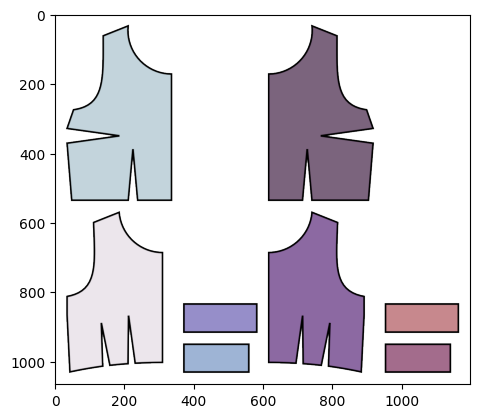

In [4]:
plt.imshow(Image.open(os.path.join(garment_path, f"{garment_id}_texture.png")))
plt.show()

# for i, (panel_name, panel) in enumerate(panel_svg_path_dict.items()):
#     fig, ax = plt.subplots()
#     ax.set_title(panel_name)
#     plot_panel_info(
#         ax, panel_name, panel_svg_path_dict, stitch_dict,
#         N_SAMPLES=1000
#     )
#     plt.show()
# for i, (panel_name, panel) in enumerate(panel_svg_path_dict.items()):
#     fig, ax = plt.subplots()
#     ax.set_title(panel_name)
#     plot_panel_info(
#         ax, panel_name, panel_svg_path_dict, stitch_dict,
#         N_SAMPLES=1000
#     )
#     plt.show()


In [6]:
for k, v in stitch_dict.items():
    panels = [v[0]['panel'], v[1]['panel']]
    if "left_ftorso" in panels and "right_ftorso" in panels:
        print(k)

20
